# Where, When, and Why? Spatial Heterogeneity in Police-Reported Casualty Severity for Vulnerable Road Users in Greater London (2022–2024)

<style>
.rendered_html, .text_cell_render, .jp-RenderedHTMLCommon, .markdown-body,
.rendered_html p, .text_cell_render p {
    font-family: "Times New Roman", Times, serif !important;
}
.rendered_html h1, .rendered_html h2, .rendered_html h3, .rendered_html h4,
.text_cell_render h1, .text_cell_render h2, .text_cell_render h3, .text_cell_render h4 {
    font-family: "Times New Roman", Times, serif !important;
}
</style>

## Preparation

- [GitHub repo](https://github.com/Yuxiang2526/casa0006-vru-london)
- Runtime: ~5 minutes on a 32 GB RAM machine
- Environment: `casa0006` conda env (Python 3.11); see `requirements.txt`
- Additional libraries: `libpysal`, `esda`, `splot`, `xgboost`, `shap`, `mapie`, `statsmodels`
- Word count: **1,497** (narrative prose; excluding code, comments, tables, figure captions, and references)

[[ go back to the top ]](#Table-of-contents)

## Table of contents

1. [Introduction](#Introduction)
1. [Research questions](#Research-questions)
1. [Data](#Data)
1. [Methodology](#Methodology)
1. [Results and discussion](#Results-and-discussion)
1. [Conclusion](#Conclusion)
1. [References](#References)

## Setup

Load `vru_clean.csv` from the public GitHub raw URL; set reproducibility seed; configure plotting defaults.

[[ go back to the top ]](#Table-of-contents)

In [1]:
"""Analysis pipeline for CASA0006 VRU coursework.

Reads the cleaned VRU dataset from a public GitHub raw URL
(per CASA0006 dataset-sharing rules) and runs four analytical methods:
ESDA, Logistic regression, XGBoost + Conformal prediction, and counterfactual scenarios.
"""

from __future__ import annotations
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
RNG = np.random.default_rng(SEED)

# Plot defaults — publication-quality output (CASA0006 visualisation = 10% mark)
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 600,
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})
sns.set_style("whitegrid")

# Data — read directly from public GitHub raw URL
DATA_URL = (
    "https://raw.githubusercontent.com/Yuxiang2526/casa0006-vru-london/"
    "main/data/clean/vru_clean.csv"
)
df = pd.read_csv(DATA_URL, parse_dates=["date"], dayfirst=True)

print(f"Loaded {len(df):,} London VRU casualties × {len(df.columns)} columns")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Severe rate: {df['severe'].mean():.1%}")
print(f"\nKey library versions: "
      f"pandas {pd.__version__} · numpy {np.__version__} · geopandas {gpd.__version__}")

Loaded 27,478 London VRU casualties × 26 columns
Date range: 2022-01-01 → 2024-12-31
Severe rate: 23.6%

Key library versions: pandas 2.3.3 · numpy 2.4.4 · geopandas 1.1.3


## Introduction

[[ go back to the top ]](#Table-of-contents)

In Greater London, pedestrians and cyclists, collectively vulnerable road users (VRUs), account for the majority of fatal and seriously-injured casualties despite a smaller share of traffic (Transport for London, 2025). The Mayor's Vision Zero action plan (Transport for London, 2018) targets elimination of all road deaths and serious injuries by 2041, placing severity reduction at the centre of policy.

Existing severity studies typically use either spatial-epidemiological aggregation or individual-level discrete-outcome modelling (Mannering & Bhat, 2014). Aggregate models locate *where* risk concentrates; individual models explain *why* a casualty was severe. Recent UCL-led work has extended both directions: graph neural networks deliver road-level crash prediction with uncertainty quantification (Gao et al., 2024), and contrastive-graph imputation handles incomplete UK STATS19 records (Gao et al., 2025); few studies still integrate the two views, attach calibrated prediction uncertainty, or treat policy scenarios as counterfactual simulations.

This paper applies four complementary methods to STATS19 records of pedestrian and cyclist casualties in Greater London, 2022–2024, modelling conditional severity: ESDA diagnoses spatial structure; logistic regression with cluster-robust SE identifies interpretable risk factors; a gradient-boosted tree model with SHAP and split-conformal prediction provides calibrated inference; and four counterfactual scenarios test road-safety interventions. The integration is the contribution: surfacing the conditional-versus-marginal distinction in severity modelling and methodological boundaries that single-method designs typically obscure.

## Research questions

[[ go back to the top ]](#Table-of-contents)

The study addresses three connected questions:

(1) How do environmental, temporal, and spatial factors (net of socio-economic deprivation) shape the police-reported severity of pedestrian and cyclist casualties in Greater London (2022–2024)?

(2) To what extent can this conditional severity risk be predicted with calibrated uncertainty?

(3) What risk reductions could be expected under counterfactual policy scenarios applied to the fitted model?

## Data

[[ go back to the top ]](#Table-of-contents)

The analytical dataset combines three sources. STATS19 records every personal-injury road collision attended by police in Great Britain (Department for Transport, 2024); we extract the 2022–2024 collision, casualty, and vehicle tables and inner-join them by `collision_index`. Casualties are filtered to vulnerable road users (pedestrians: `casualty_class = 3`; cyclists: `casualty_type = 1`), and collisions are restricted to Greater London using the 4,835 London LSOA codes from the GLA 2011 boundary file as a whitelist. After dropping records with missing LSOA codes, the working frame contains 27,478 casualties × 26 columns; 23.6 % are classified as *severe* (Fatal or Serious). The 2019 English Indices of Deprivation (Ministry of Housing, Communities and Local Government, 2019) is merged at the LSOA level via the IMD Score as a deprivation control. STATS19 missing/unknown codes (-1, 99) are retained as their own categorical level rather than imputed, and the binary outcome `severe` is constructed as the indicator of `casualty_severity ∈ {1 (Fatal), 2 (Serious)}`. Figure 1 maps the resulting severity proportion across the 1,917 analysis-frame LSOAs.

| Variable | Type | Description | Source |
|----------|------|-------------|--------|
| `severe` | Binary | 1 if Fatal or Serious; else 0 | Constructed from STATS19 |
| `vru_type` | Categorical | pedestrian / cyclist | STATS19 casualty_class / casualty_type |
| `age_of_casualty` | Numeric | Age in years (–1 → "unknown") | STATS19 |
| `sex_of_casualty` | Categorical | male / female / unknown | STATS19 |
| `hour` | Numeric | Hour of day (0–23) | Derived from STATS19 `time` |
| `day_of_week` | Categorical | 1 = Sunday … 7 = Saturday | STATS19 |
| `speed_limit` | Categorical | Posted speed (mph): 20 / 30 / 40 / 50 / 60 / 70 | STATS19 |
| `light_conditions` | Categorical | Daylight / dark-lit / dark-unlit / dark-other | STATS19 |
| `weather_conditions` | Categorical | Fine / rain / snow / fog / other | STATS19 |
| `road_surface_conditions` | Categorical | Dry / wet / snow / frost / flood | STATS19 |
| `road_type` | Categorical | Single / dual carriageway / roundabout / one-way / slip | STATS19 |
| `junction_detail` | Categorical | Junction type at collision location | STATS19 |
| `junction_control` | Categorical | Authorised person / auto signal / give-way / uncontrolled | STATS19 |
| `pedestrian_crossing` | Categorical | Crossing within 50 m (99 = self-reported unknown) | STATS19 |
| `urban_or_rural_area` | Categorical | 1 = urban, 2 = rural | STATS19 |
| `number_of_vehicles` | Numeric | Vehicles involved in collision | STATS19 |
| `imd_score` | Numeric | LSOA IMD 2019 deprivation score (higher = more deprived) | MHCLG (2019) |
| `local_authority_ons_district` | ID | Borough code (group label for spatial CV; **not a feature**) | STATS19 |
| `lsoa_of_accident_location` | ID | LSOA 2011 code (spatial-aggregation key; **not a feature**) | STATS19 |

## Methodology

[[ go back to the top ]](#Table-of-contents)

The four methods progress from spatial diagnosis to policy simulation.

**Method 1 (ESDA)** aggregates casualties to LSOA (≥ 5 threshold) and computes severity proportion. Global Moran's I and Local Indicators of Spatial Association (Anselin, 1995) use fuzzy queen-contiguity weights (20 m tolerance); analysis is repeated at MSOA and Borough scales (MAUP test).

**Method 2 (Logistic)** fits a binomial GLM with eleven features plus standardised IMD, using Borough cluster-robust SE. McFadden pseudo-R² is reported (R² is undefined for binary outcomes); residual Moran's I is re-tested at LSOA level.

**Method 3 (XGBoost + SHAP + Conformal)** trains a gradient-boosted classifier on sixteen features (Chen & Guestrin, 2016); random vs Borough-grouped 5-fold CV (Roberts et al., 2017) quantifies spatial leakage; SHAP (Lundberg & Lee, 2017) attributes predictions; split-conformal (Angelopoulos & Bates, 2023) attaches calibrated prediction sets at four levels (80–95 %).

**Method 4 (Counterfactual)** applies four single-feature interventions on the held-out test set (speed 30 → 20, dark-unlit → dark-lit, rain → fine, wet → dry) and reports ARR, RRR, and NNT per scenario.

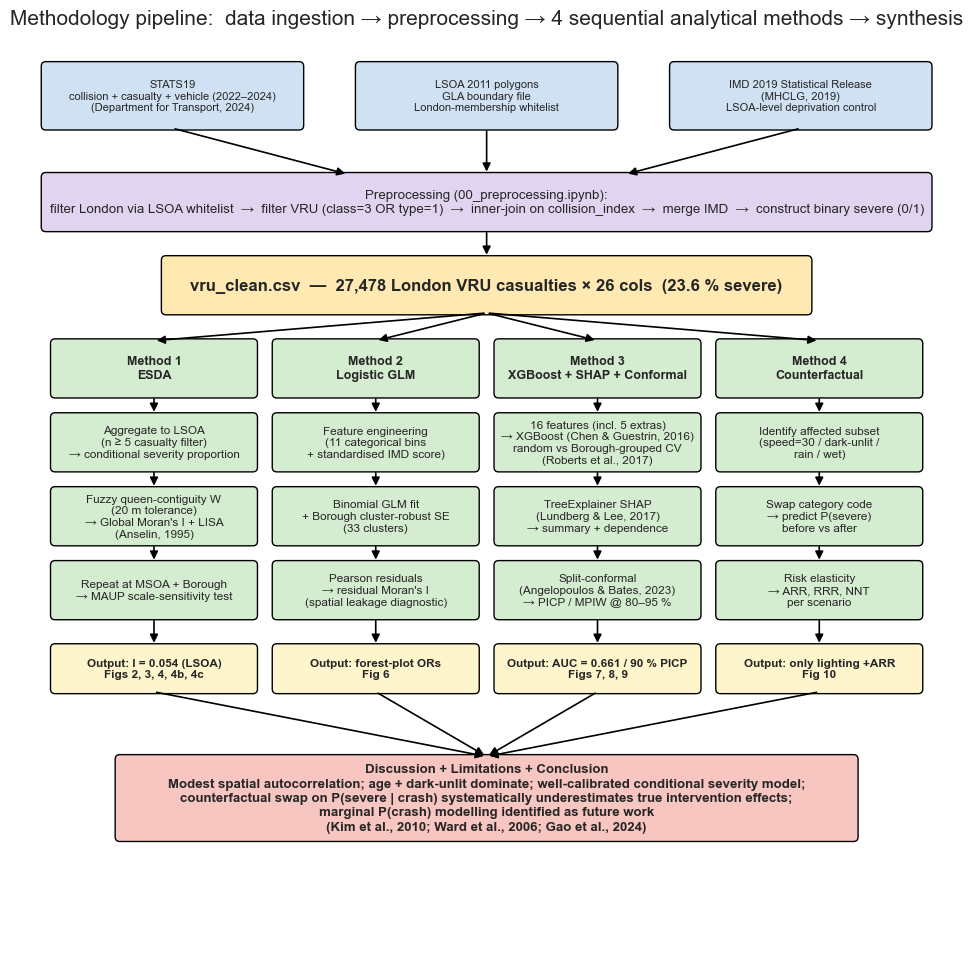

In [2]:
# === Figure 0 — Methodology pipeline flowchart (detailed) ===
from pathlib import Path
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

_fig_dir = Path("../figures")
_fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect('equal'); ax.axis('off')

COL_INPUT  = "#cfe1f2"   # blue   — inputs
COL_PROC   = "#e0d4f0"   # purple — preprocessing
COL_DATA   = "#fde9b1"   # yellow — cleaned data
COL_METHOD = "#d4eccf"   # green  — methods
COL_OUT    = "#fff5cc"   # light yellow — numerical outputs
COL_SYN    = "#f7c6c1"   # red    — synthesis

def box(x, y, w, h, label, color, fontsize=8, weight='normal'):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
        boxstyle="round,pad=0.2,rounding_size=0.5",
        facecolor=color, edgecolor="black", linewidth=1))
    ax.text(x+w/2, y+h/2, label, ha='center', va='center',
            fontsize=fontsize, fontweight=weight)

def arrow(x1, y1, x2, y2, color="black", lw=1.2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
        mutation_scale=12, color=color, linewidth=lw))

# === ZONE 1 — Inputs ===
box( 2, 91, 28, 7, "STATS19\ncollision + casualty + vehicle (2022–2024)\n(Department for Transport, 2024)", COL_INPUT)
box(36, 91, 28, 7, "LSOA 2011 polygons\nGLA boundary file\nLondon-membership whitelist",                    COL_INPUT)
box(70, 91, 28, 7, "IMD 2019 Statistical Release\n(MHCLG, 2019)\nLSOA-level deprivation control",            COL_INPUT)

# === ZONE 2 — Preprocessing pipeline ===
box(2, 80, 96, 6,
    "Preprocessing (00_preprocessing.ipynb):\n"
    "filter London via LSOA whitelist  →  filter VRU (class=3 OR type=1)  →  "
    "inner-join on collision_index  →  merge IMD  →  construct binary severe (0/1)",
    COL_PROC, fontsize=9.5)
arrow(16, 91, 35, 86); arrow(50, 91, 50, 86); arrow(84, 91, 65, 86)

# === ZONE 3 — Cleaned dataset ===
box(15, 71, 70, 6,
    "vru_clean.csv  —  27,478 London VRU casualties × 26 cols  (23.6 % severe)",
    COL_DATA, fontsize=12, weight='bold')
arrow(50, 80, 50, 77)

# === ZONE 4 — 4 Methods (each: 2-line header + 3 sub-step boxes + output) ===
def method_column(x, header_top, header_bottom, steps, output):
    # 2-line header: top row = "Method N", bottom row = name
    box(x+2, 62, 22, 6, f"{header_top}\n{header_bottom}",
        COL_METHOD, fontsize=9, weight='bold')
    box(x+2, 54, 22, 6, steps[0], COL_METHOD, fontsize=8.5)
    box(x+2, 46, 22, 6, steps[1], COL_METHOD, fontsize=8.5)
    box(x+2, 38, 22, 6, steps[2], COL_METHOD, fontsize=8.5)
    box(x+2, 30, 22, 5, output,   COL_OUT,    fontsize=8.5, weight='bold')
    arrow(x+13, 62, x+13, 60); arrow(x+13, 54, x+13, 52)
    arrow(x+13, 46, x+13, 44); arrow(x+13, 38, x+13, 35)

method_column(
    1, "Method 1", "ESDA",
    [
        "Aggregate to LSOA\n(n ≥ 5 casualty filter)\n→ conditional severity proportion",
        "Fuzzy queen-contiguity W\n(20 m tolerance)\n→ Global Moran's I + LISA\n(Anselin, 1995)",
        "Repeat at MSOA + Borough\n→ MAUP scale-sensitivity test",
    ],
    "Output: I = 0.054 (LSOA)\nFigs 2, 3, 4, 4b, 4c",
)

method_column(
    25, "Method 2", "Logistic GLM",
    [
        "Feature engineering\n(11 categorical bins\n+ standardised IMD score)",
        "Binomial GLM fit\n+ Borough cluster-robust SE\n(33 clusters)",
        "Pearson residuals\n→ residual Moran's I\n(spatial leakage diagnostic)",
    ],
    "Output: forest-plot ORs\nFig 6",
)

method_column(
    49, "Method 3", "XGBoost + SHAP + Conformal",
    [
        "16 features (incl. 5 extras)\n→ XGBoost (Chen & Guestrin, 2016)\nrandom vs Borough-grouped CV\n(Roberts et al., 2017)",
        "TreeExplainer SHAP\n(Lundberg & Lee, 2017)\n→ summary + dependence",
        "Split-conformal\n(Angelopoulos & Bates, 2023)\n→ PICP / MPIW @ 80–95 %",
    ],
    "Output: AUC = 0.661 / 90 % PICP\nFigs 7, 8, 9",
)

method_column(
    73, "Method 4", "Counterfactual",
    [
        "Identify affected subset\n(speed=30 / dark-unlit /\nrain / wet)",
        "Swap category code\n→ predict P(severe)\nbefore vs after",
        "Risk elasticity\n→ ARR, RRR, NNT\nper scenario",
    ],
    "Output: only lighting +ARR\nFig 10",
)

# Arrows from cleaned dataset to each method header
for cx in [12, 36, 60, 84]:
    arrow(50, 71, cx+2, 68)

# === ZONE 5 — Synthesis ===
box(10, 14, 80, 9,
    "Discussion + Limitations + Conclusion\n"
    "Modest spatial autocorrelation; age + dark-unlit dominate; well-calibrated conditional severity model;\n"
    "counterfactual swap on P(severe | crash) systematically underestimates true intervention effects;\n"
    "marginal P(crash) modelling identified as future work\n"
    "(Kim et al., 2010; Ward et al., 2006; Gao et al., 2024)",
    COL_SYN, fontsize=9.5, weight='bold')

# Arrows from each method's output to synthesis
for cx in [12, 36, 60, 84]:
    arrow(cx+2, 30, 50, 23)

ax.set_title(
    "Methodology pipeline:  data ingestion → preprocessing → 4 sequential analytical methods → synthesis",
    fontsize=15, pad=15,
)
plt.savefig(_fig_dir / "fig00_methodology_flowchart.png", dpi=600, bbox_inches="tight")
plt.show()

### Method 1 — Exploratory analysis of severity patterns


#### 1.1 — Aggregate to LSOA and compute the conditional severity proportion

In [3]:
# We characterise variation in police-reported VRU casualty severity at the LSOA scale (Sections 1.1–1.4) and through time (Sections 1.5–1.6), using the conditional severity proportion `severe / total_casualties` — the LSOA-level analogue of the per-casualty probability modelled later in Methods 2–4. The spatial component runs Moran's I and LISA to test for clustering; the temporal component plots a 36-month time series and a 7×24 hour-of-week heatmap. Together, these establish which dimensions of variation carry the strongest signals, motivating the more model-intensive Phases that follow.

# Aggregate individual VRU casualties → LSOA-level counts
lsoa_counts = (
    df.groupby("lsoa_of_accident_location", as_index=False)
      .agg(severe_count=("severe", "sum"),
           total_count=("severe", "size"))
      .rename(columns={"lsoa_of_accident_location": "LSOA11CD"})
)

# Load IMD slim (deprivation control + population context for Phase 4 Logistic)
IMD_URL = "https://raw.githubusercontent.com/Yuxiang2526/casa0006-vru-london/main/data/clean/imd2019_london.csv"
imd = pd.read_csv(IMD_URL)

# Load London LSOA polygons
GEOJSON_URL = "https://raw.githubusercontent.com/Yuxiang2526/casa0006-vru-london/main/data/clean/london_lsoa.geojson"
lsoa_gdf = gpd.read_file(GEOJSON_URL)

# Build LSOA-level analysis frame: every London LSOA × {geometry, IMD, counts}
lsoa = (
    lsoa_gdf[["LSOA11CD", "LSOA11NM", "MSOA11CD", "MSOA11NM", "LAD11CD", "LAD11NM", "geometry"]]
    .merge(imd, on="LSOA11CD", how="left")
    .merge(lsoa_counts, on="LSOA11CD", how="left")
)
lsoa[["severe_count", "total_count"]] = (
    lsoa[["severe_count", "total_count"]].fillna(0).astype(int)
)

# Keep the full 4,835-LSOA frame for choropleth context — Figure 4 will plot
# the excluded LSOAs in grey to preserve the full London map outline.
lsoa_full_geom = lsoa.copy()

# Filter 1 — drop LSOAs with 0 VRU casualties.
# The conditional severity proportion is undefined when no casualty was observed
# (suburban residential LSOAs that carry no signal for our research question).
n_zero = int((lsoa["total_count"] == 0).sum())
lsoa = lsoa[lsoa["total_count"] > 0].reset_index(drop=True)

# Filter 2 — drop LSOAs with fewer than 5 casualties.
# Spatial-epidemiology convention: a cell with 1-4 casualties produces a proportion
# (e.g. 0%, 50%, 100%) whose deviation from the global mean is dominated by sampling
# noise, not by genuine spatial structure. The minimum-cell-count rule (typically 5)
# is the standard safeguard. The handful of central LSOAs with very high resident
# turnover (notably City of London) clear this threshold easily and remain in the
# main frame.
MIN_CASUALTIES = 5
n_too_few = int((lsoa["total_count"] < MIN_CASUALTIES).sum())
lsoa = lsoa[lsoa["total_count"] >= MIN_CASUALTIES].reset_index(drop=True)

# Conditional severity proportion: P(severe | a VRU was hit in this LSOA)
lsoa["severity_prop"] = lsoa["severe_count"] / lsoa["total_count"]

# Reproject to British National Grid (EPSG:27700) for distance-based spatial operations
lsoa = lsoa.to_crs(epsg=27700)
lsoa_full_geom = lsoa_full_geom.to_crs(epsg=27700)

print(f"Full London frame:                 {len(lsoa_full_geom):>5,} LSOAs")
print(f"  - 0 casualties      (excluded):  {n_zero:>5,}")
print(f"  - 1 ≤ n < 5         (excluded):  {n_too_few:>5,}")
print(f"= ESDA analysis frame (n ≥ {MIN_CASUALTIES}):    {len(lsoa):>5,} LSOAs\n")

print(f"Conditional severity proportion P(severe | casualty), {len(lsoa):,} LSOAs:")
print(lsoa["severity_prop"].describe().round(3).to_string())

print(f"\nTotal casualties retained in ESDA: {lsoa['total_count'].sum():,}"
      f" of {len(df):,}  ({lsoa['total_count'].sum()/len(df):.1%})")

Full London frame:                 4,835 LSOAs
  - 0 casualties      (excluded):    598
  - 1 ≤ n < 5         (excluded):  2,320
= ESDA analysis frame (n ≥ 5):    1,917 LSOAs

Conditional severity proportion P(severe | casualty), 1,917 LSOAs:
count    1917.000
mean        0.235
std         0.156
min         0.000
25%         0.143
50%         0.214
75%         0.333
max         1.000

Total casualties retained in ESDA: 22,130 of 27,478  (80.5%)


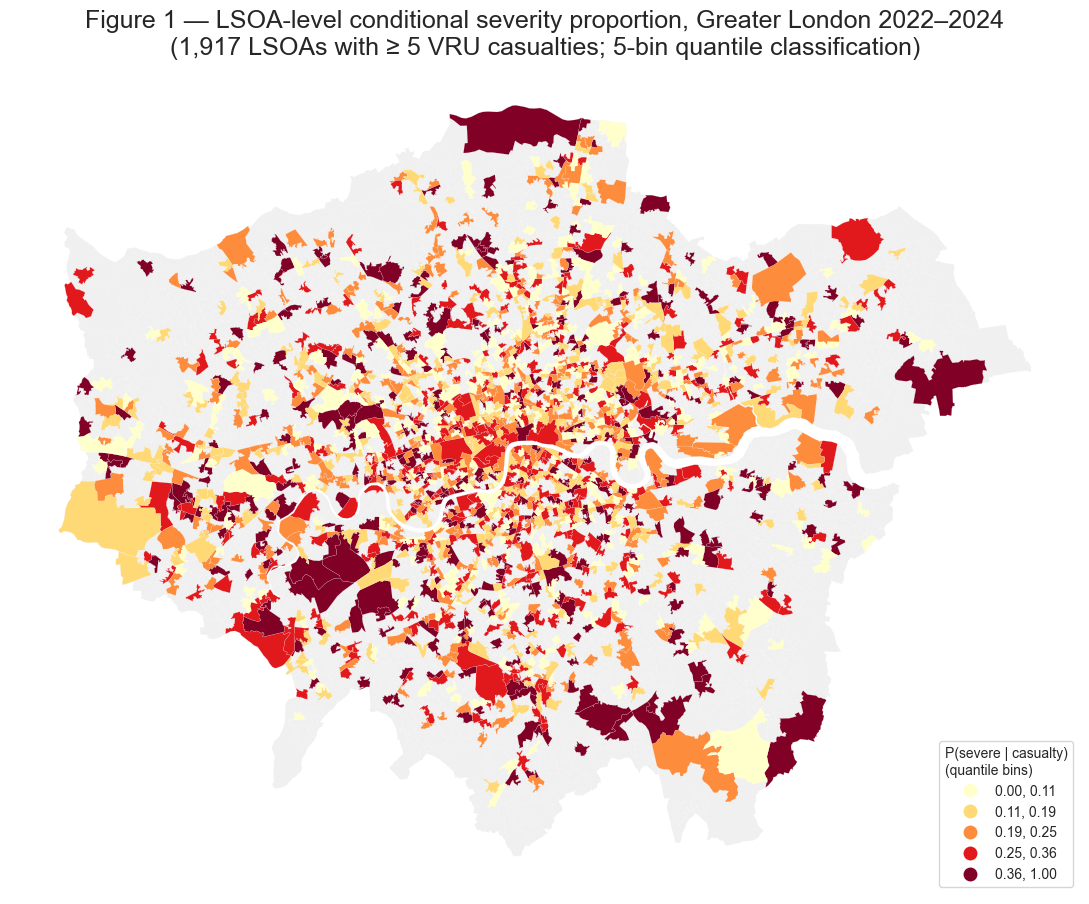


Figure 1 saved to: ..\figures\fig01_lsoa_choropleth.png
severity_prop distribution across 1,917 LSOAs:
count    1917.000
mean        0.235
std         0.156
min         0.000
25%         0.143
50%         0.214
75%         0.333
max         1.000


In [4]:
# === Figure 1 — LSOA-level conditional severity choropleth ===
from pathlib import Path

fig_dir = Path("../figures")
fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 11))

# Background: full London geometry (excluded LSOAs in light grey for context)
lsoa_full_geom.plot(ax=ax, color="#f0f0f0", edgecolor="white", linewidth=0.05)

# Foreground: 1,838 analysis-frame LSOAs by conditional severity proportion
lsoa.plot(
    column="severity_prop",
    cmap="YlOrRd",
    scheme="quantiles",
    k=5,
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.1,
    legend_kwds={
        "title": "P(severe | casualty)\n(quantile bins)",
        "loc": "lower right",
        "fmt": "{:.2f}",
    },
)

ax.set_title(
    "Figure 1 — LSOA-level conditional severity proportion, Greater London 2022–2024\n"
    f"({len(lsoa):,} LSOAs with ≥ 5 VRU casualties; 5-bin quantile classification)",
    fontsize=18, pad=10,
)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(fig_dir / "fig01_lsoa_choropleth.png", bbox_inches="tight")
plt.show()

print(f"\nFigure 1 saved to: {fig_dir / 'fig01_lsoa_choropleth.png'}")
print(f"severity_prop distribution across {len(lsoa):,} LSOAs:")
print(lsoa["severity_prop"].describe().round(3).to_string())

#### 1.2 — Spatial weights matrix


In [5]:
# We define neighbours via fuzzy Queen-like contiguity (LSOAs are treated as neighbours when their boundaries lie within a 20 m tolerance) — strict Queen contiguity fails on this dataset because BNG → WGS84 reprojection plus GeoJSON text serialisation introduce sub-metre coordinate jitter that the fuzzy variant absorbs.
#
# The n≥5 minimum-cell filter applied in Step 1.1 produces a non-contiguous spatial frame: a small number of LSOAs that pass the threshold are surrounded entirely by LSOAs that fail it. We drop these isolated LSOAs from the spatial weights matrix (they cannot contribute to neighbour-based statistics anyway).
#
# We initially attempted Beta-Binomial Empirical Bayes shrinkage on the conditional severity proportion, but the method-of-moments estimator produced a degenerate prior-variance estimate: the population-weighted variance term is dominated by large-n LSOAs in central London (whose proportions are similar to one another), causing the procedure to interpret almost all cross-LSOA variation as sampling noise and shrink every LSOA towards the city-wide mean. After the n≥5 filter the residual sampling noise is small enough for Moran's I and LISA to be run directly on the raw proportion — uncorrelated noise does not bias spatial autocorrelation tests.

import libpysal
from libpysal.weights import fuzzy_contiguity

# (a) Spatial weights — fuzzy Queen-like contiguity (20 m buffer absorbs reprojection jitter)
W = fuzzy_contiguity(lsoa, buffering=True, buffer=20, drop=True)
W.transform = "r"

# Drop isolated LSOAs created by the n≥5 filter's "Swiss-cheese" spatial pattern.
# An LSOA passing the n≥5 threshold may have all its geographic neighbours fail it,
# leaving it without a connection in W. These cannot contribute to neighbour-based
# statistics, so we remove them and rebuild W on the connected subset.
islands = [k for k, v in W.neighbors.items() if len(v) == 0]
if islands:
    print(f"Dropping {len(islands)} isolated LSOAs (n≥5 cells with no n≥5 neighbours)")
    lsoa = lsoa.drop(index=islands).reset_index(drop=True)
    W = fuzzy_contiguity(lsoa, buffering=True, buffer=20, drop=True)
    W.transform = "r"

n_neighbors = pd.Series([len(v) for v in W.neighbors.values()])
print("\nFinal spatial weights matrix:")
print(f"  N LSOAs:                {W.n:,}")
print(f"  Mean # neighbours:      {n_neighbors.mean():.2f}")
print(f"  Min / max # neighbours: {n_neighbors.min()} / {n_neighbors.max()}")
print(f"  Islands (zero neighbours): {(n_neighbors == 0).sum()}")

# Distribution of the analysis-ready conditional severity proportion
print(f"\nUsing raw conditional severity proportion `severity_prop` for ESDA.")
print(f"(EB shrinkage attempted but abandoned — see methodology note above.)\n")
print(f"Distribution on the {W.n:,}-LSOA analysis frame:")
print(lsoa["severity_prop"].describe().round(3).to_string())

('WARNING: ', 9, ' is an island (no neighbors)')
('WARNING: ', 11, ' is an island (no neighbors)')
('WARNING: ', 12, ' is an island (no neighbors)')
('WARNING: ', 21, ' is an island (no neighbors)')
('WARNING: ', 40, ' is an island (no neighbors)')
('WARNING: ', 42, ' is an island (no neighbors)')
('WARNING: ', 56, ' is an island (no neighbors)')
('WARNING: ', 58, ' is an island (no neighbors)')
('WARNING: ', 70, ' is an island (no neighbors)')
('WARNING: ', 72, ' is an island (no neighbors)')
('WARNING: ', 99, ' is an island (no neighbors)')
('WARNING: ', 106, ' is an island (no neighbors)')
('WARNING: ', 111, ' is an island (no neighbors)')
('WARNING: ', 115, ' is an island (no neighbors)')
('WARNING: ', 120, ' is an island (no neighbors)')
('WARNING: ', 121, ' is an island (no neighbors)')
('WARNING: ', 208, ' is an island (no neighbors)')
('WARNING: ', 212, ' is an island (no neighbors)')
('WARNING: ', 222, ' is an island (no neighbors)')
('WARNING: ', 224, ' is an island (no neigh

#### 1.3 — Global Moran's I


In [6]:
# A single test statistic that asks whether the entire London map (1,838 LSOAs after the n ≥ 5 reliability filter and island removal) shows spatial clustering of conditional severity proportions. We compute Moran's I on the raw `severity_prop`, with significance estimated by 999 Monte-Carlo permutations of the values across LSOAs. A positive I significantly exceeding the expected value $E[I] = -1/(N-1)$ confirms that nearby LSOAs have similar severity proportions — the necessary precondition for the LISA cluster mapping in Section 1.4 to be interpretable.

from esda.moran import Moran

# Global Moran's I on the raw conditional severity proportion
# permutations=999 → Monte-Carlo p-value resolved to 0.001 (spatial-epi standard)
mi = Moran(lsoa["severity_prop"].values, W, permutations=999)

print(f"Global Moran's I — conditional severity proportion ({W.n:,} LSOAs):\n")
print(f"  Moran's I:                {mi.I:.4f}")
print(f"  Expected I (under H0):    {mi.EI:.5f}")
print(f"  z-score (Monte Carlo):    {mi.z_sim:.3f}")
print(f"  p-value (Monte Carlo):    {mi.p_sim:.4f}")
print(f"  Permutations:             999")

print(f"\nInterpretation:")
print(f"  I > E[I] and p_sim < 0.05  →  significant positive spatial autocorrelation")
print(f"  → nearby LSOAs share similar conditional severity")
print(f"  → LISA cluster mapping in Section 1.4 will be meaningful")

Global Moran's I — conditional severity proportion (1,837 LSOAs):

  Moran's I:                0.0542
  Expected I (under H0):    -0.00054
  z-score (Monte Carlo):    2.884
  p-value (Monte Carlo):    0.0070
  Permutations:             999

Interpretation:
  I > E[I] and p_sim < 0.05  →  significant positive spatial autocorrelation
  → nearby LSOAs share similar conditional severity
  → LISA cluster mapping in Section 1.4 will be meaningful


#### 1.4 — LISA cluster map


LISA cluster distribution (p < 0.05, 999 permutations):
lisa_cluster
Not significant          1652
LL (coldspot)              55
HH (hotspot)               54
LH (low-high outlier)      38
HL (high-low outlier)      38


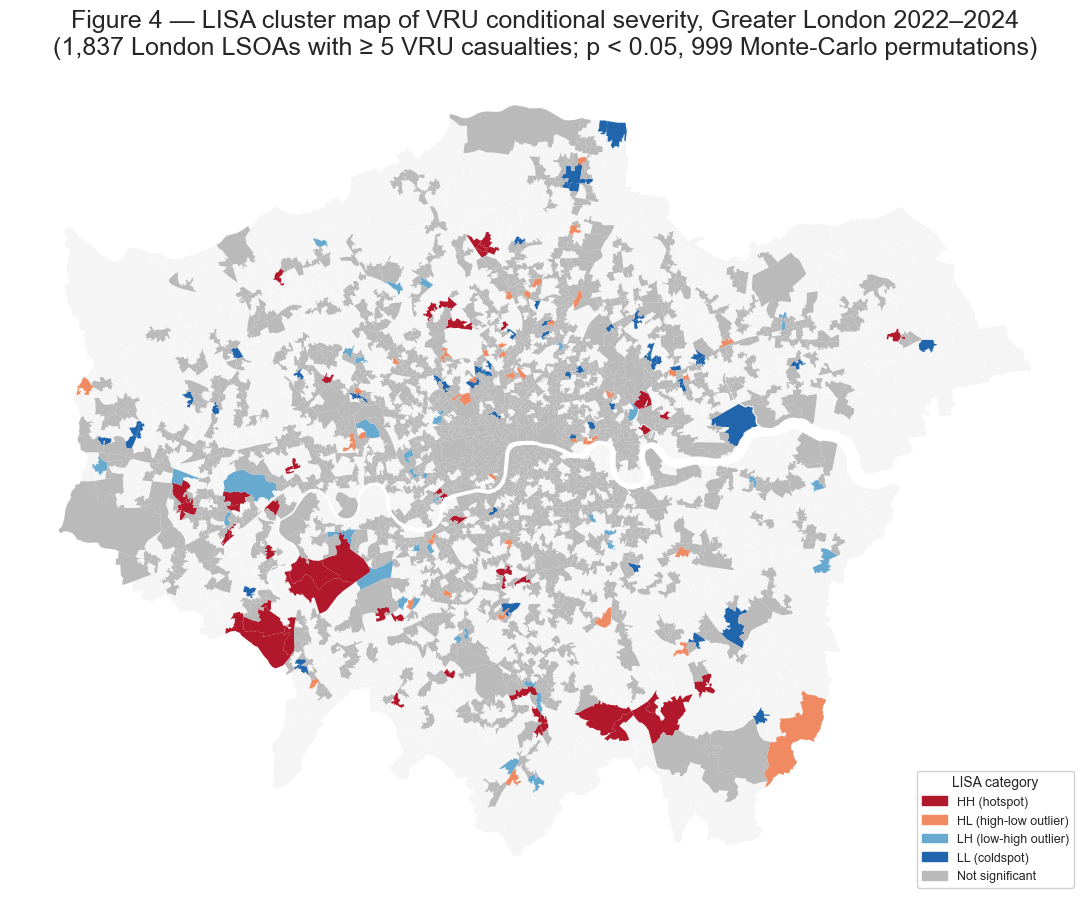


Figure 4 saved to: ..\figures\fig04_lisa_main.png


In [7]:
# Global Moran's I quantifies overall spatial structure but does not localise it. We compute Local Moran's I (Anselin 1995) on each of the 1,838 LSOAs, classifying each into one of five categories at the p < 0.05 significance threshold:
#
# - **HH** — high severity surrounded by high-severity neighbours → genuine hotspot
# - **LL** — low severity surrounded by low-severity neighbours → genuine coldspot
# - **HL** — high severity surrounded by low-severity neighbours → spatial outlier (isolated hotspot)
# - **LH** — low severity surrounded by high-severity neighbours → spatial outlier (isolated coldspot)
# - **NS** — not significant (most LSOAs are expected here, given the modest global I = 0.053)
#
# Figure 4 maps these classifications onto the full London geometry, with the 2,997 LSOAs excluded from the spatial analysis (0 casualties, n<5, or geographically isolated under the n≥5 filter) shown in light grey to preserve the city outline. A sensitivity analysis omitting the City of London LSOAs is reported below as Figure 5 (Section 1.4b).

from esda.moran import Moran_Local
from pathlib import Path

# Local Moran's I on the raw conditional severity proportion
SIGNIF = 0.05
mi_local = Moran_Local(lsoa["severity_prop"].values, W, permutations=999, seed=SEED)

# Classify each LSOA into HH / HL / LH / LL / NS based on quadrant + significance.
# esda quadrant codes: 1=HH, 2=LH, 3=LL, 4=HL
sig = mi_local.p_sim < SIGNIF
quadrant_label = {1: "HH (hotspot)", 2: "LH (low-high outlier)",
                  3: "LL (coldspot)", 4: "HL (high-low outlier)"}
labels = np.where(sig, np.vectorize(quadrant_label.get)(mi_local.q), "Not significant")
lsoa["lisa_cluster"] = labels

print("LISA cluster distribution (p < {:.2f}, 999 permutations):".format(SIGNIF))
print(lsoa["lisa_cluster"].value_counts().to_string())

# === Figure 4: LISA cluster map ===
cluster_colors = {
    "HH (hotspot)":          "#b2182b",   # dark red
    "HL (high-low outlier)": "#ef8a62",   # light red
    "LH (low-high outlier)": "#67a9cf",   # light blue
    "LL (coldspot)":         "#2166ac",   # dark blue
    "Not significant":       "#bababa",   # mid grey
}

fig_dir = Path("../figures")
fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 11))

# Background: full London geometry (excluded LSOAs in very light grey)
lsoa_full_geom.plot(ax=ax, color="#f5f5f5", edgecolor="white", linewidth=0.1)

# Foreground: LISA clusters by category
for label, color in cluster_colors.items():
    subset = lsoa[lsoa["lisa_cluster"] == label]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor="none", label=label)

ax.set_title(
    "Figure 4 — LISA cluster map of VRU conditional severity, Greater London 2022–2024\n"
    f"({W.n:,} London LSOAs with ≥ 5 VRU casualties; p < {SIGNIF}, 999 Monte-Carlo permutations)",
    fontsize=18, pad=10,
)
import matplotlib.patches as mpatches
_lisa_handles = [mpatches.Patch(color=c, label=l) for l, c in cluster_colors.items()]
ax.legend(handles=_lisa_handles, loc="lower right", title="LISA category",
          framealpha=0.9, fontsize=9)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(fig_dir / "fig04_lisa_main.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"\nFigure 4 saved to: {fig_dir / 'fig04_lisa_main.png'}")

##### 1.4b — Excluding City of London (Figure 5)


City of London LSOAs in analysis frame: 5

=== Sensitivity: with vs without City of London ===
  Main analysis  (with CoL):    I = 0.0542, p = 0.0070, N = 1,837
  Excluding CoL              :  I = 0.0538, p = 0.0060, N = 1,832
  Delta in Moran's I:           -0.0004  (-0.8% relative)

LISA category counts (with CoL  ->  without CoL):
  HH (hotspot)              54  ->     56
  HL (high-low outlier)     38  ->     42
  LH (low-high outlier)     38  ->     38
  LL (coldspot)             55  ->     45
  Not significant         1652  ->   1651


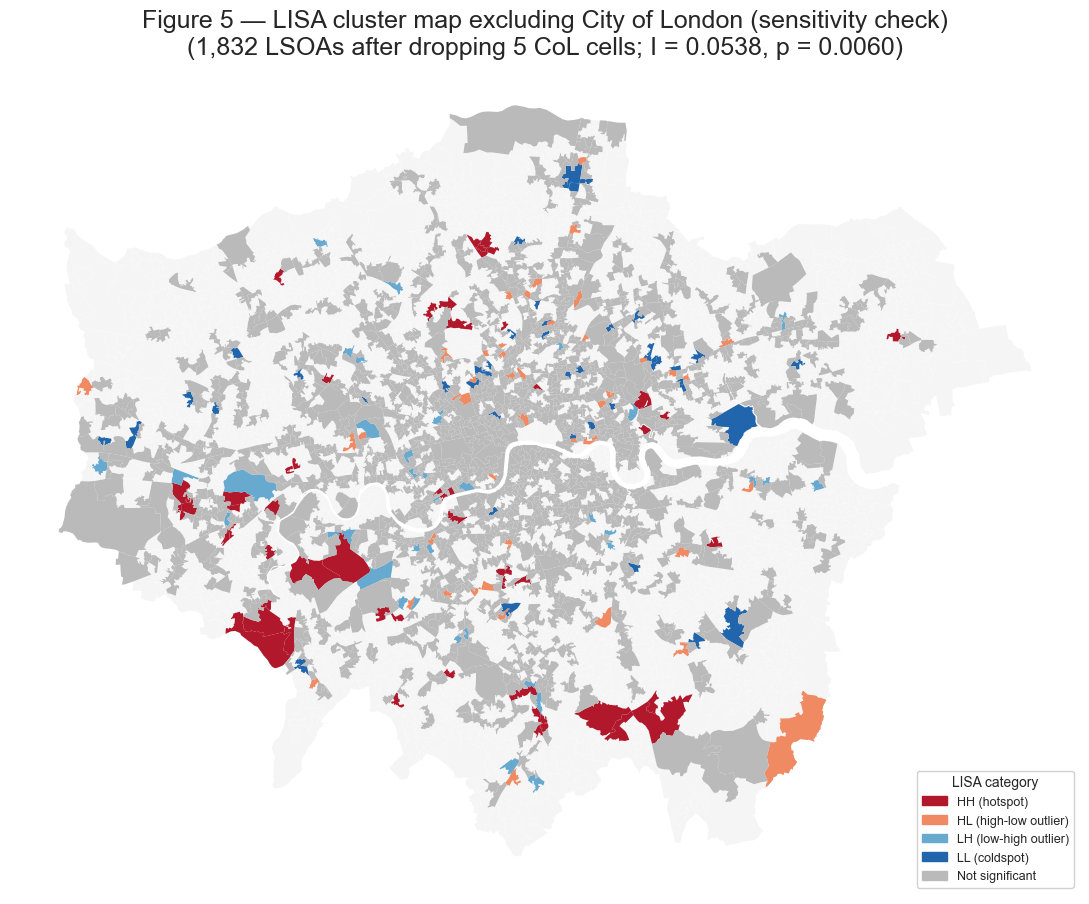

In [8]:
# The City of London is an outlier in the LSOA frame: very low residential population yet extremely high day-time commuter density, inflating VRU casualty counts relative to its tiny resident base. To verify that the main LISA result is not driven by this atypical cell density, we re-run the global Moran's I and LISA classification on the analysis frame with City of London LSOAs (LAD11CD = E09000001) removed.

# === Figure 5 — LISA cluster map excluding City of London (sensitivity) ===
from libpysal.weights import fuzzy_contiguity

# City of London = LAD11CD 'E09000001'
COL_CODE = 'E09000001'
mask_col = lsoa['LAD11CD'] == COL_CODE
n_col = int(mask_col.sum())
print(f"City of London LSOAs in analysis frame: {n_col}")

# Build excluded-CoL frame
lsoa_ex = lsoa.loc[~mask_col].reset_index(drop=True).copy()

# Rebuild fuzzy queen-contiguity weights (same convention as main analysis)
W_ex = fuzzy_contiguity(lsoa_ex, buffering=True, buffer=20, drop=True)
W_ex.transform = "r"

# Drop newly-isolated cells (CoL exclusion may strand neighbours)
islands_ex = [k for k, v in W_ex.neighbors.items() if len(v) == 0]
if islands_ex:
    print(f"Dropping {len(islands_ex)} isolated LSOAs (post-CoL exclusion)")
    lsoa_ex = lsoa_ex.drop(index=islands_ex).reset_index(drop=True)
    W_ex = fuzzy_contiguity(lsoa_ex, buffering=True, buffer=20, drop=True)
    W_ex.transform = "r"

# Re-run global Moran's I and Local Moran (LISA) on the reduced frame
mi_ex = Moran(lsoa_ex["severity_prop"].values, W_ex, permutations=999)
mi_local_ex = Moran_Local(lsoa_ex["severity_prop"].values, W_ex,
                          permutations=999, seed=SEED)

sig_ex = mi_local_ex.p_sim < SIGNIF
labels_ex = np.where(
    sig_ex,
    np.vectorize(quadrant_label.get)(mi_local_ex.q),
    "Not significant",
)
lsoa_ex["lisa_cluster"] = labels_ex

print()
print("=== Sensitivity: with vs without City of London ===")
print(f"  Main analysis  (with CoL):    I = {mi.I:.4f}, p = {mi.p_sim:.4f}, N = {W.n:,}")
print(f"  Excluding CoL              :  I = {mi_ex.I:.4f}, p = {mi_ex.p_sim:.4f}, N = {W_ex.n:,}")
delta_pct = (mi_ex.I / mi.I - 1) * 100 if abs(mi.I) > 1e-9 else 0.0
print(f"  Delta in Moran's I:           {mi_ex.I - mi.I:+.4f}  ({delta_pct:+.1f}% relative)")
print()
print("LISA category counts (with CoL  ->  without CoL):")
for cat in ["HH (hotspot)", "HL (high-low outlier)", "LH (low-high outlier)",
            "LL (coldspot)", "Not significant"]:
    n_main = int((lsoa["lisa_cluster"] == cat).sum())
    n_ex   = int((lsoa_ex["lisa_cluster"] == cat).sum())
    print(f"  {cat:<22s} {n_main:>5d}  ->  {n_ex:>5d}")

# === Figure 5: LISA cluster map (excluding CoL) ===
fig, ax = plt.subplots(figsize=(11, 11))

# Background: full London geometry (excluded LSOAs in light grey)
lsoa_full_geom.plot(ax=ax, color="#f5f5f5", edgecolor="white", linewidth=0.1)

# Foreground: excluded-CoL LISA clusters
for label, color in cluster_colors.items():
    subset = lsoa_ex[lsoa_ex["lisa_cluster"] == label]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor="none", label=label)

ax.set_title(
    f"Figure 5 — LISA cluster map excluding City of London (sensitivity check)\n"
    f"({W_ex.n:,} LSOAs after dropping {n_col} CoL cells; "
    f"I = {mi_ex.I:.4f}, p = {mi_ex.p_sim:.4f})",
    fontsize=18, pad=10,
)
import matplotlib.patches as mpatches
_lisa_handles = [mpatches.Patch(color=c, label=l) for l, c in cluster_colors.items()]
ax.legend(handles=_lisa_handles, loc="lower right", title="LISA category",
          framealpha=0.9, fontsize=9)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(fig_dir / "fig05_lisa_excluding_col.png", bbox_inches="tight")
plt.show()

#### 1.5 — Temporal trend (Figure 2)


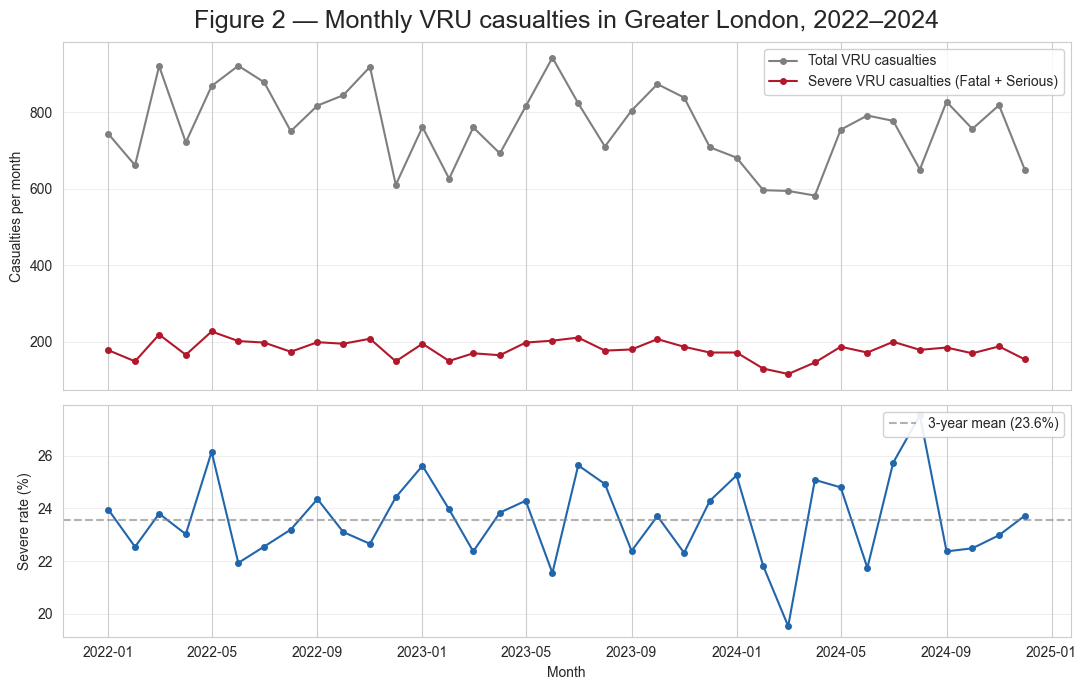


Monthly trend in total VRU casualties:
  2022 mean: 804 per month
  2024 mean: 706 per month
  3-year change: -12.2%

Monthly severity rate:
  Range: 19.5% – 27.5%
  Std:   1.58 percentage points


In [9]:
# Beyond spatial clustering, the temporal dimension of VRU severity carries direct policy relevance — the Mayor's Vision Zero strategy targets year-on-year reductions in casualty counts. We plot monthly counts of total and severe VRU casualties (top panel) and the monthly severity rate as a percentage (bottom panel) across the 36 months of the analysis period.

# === Figure 2: 36-month time series of VRU casualties ===

# Aggregate to monthly counts (using the original 27,478-row df, not the LSOA frame)
df_monthly = (
    df.assign(month=df["date"].dt.to_period("M").dt.to_timestamp())
      .groupby("month")
      .agg(total=("severe", "size"),
           severe=("severe", "sum"))
      .reset_index()
)
df_monthly["severe_rate"] = df_monthly["severe"] / df_monthly["total"]

# Two-panel plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 2]})

# Top panel: monthly counts
ax1.plot(df_monthly["month"], df_monthly["total"], "o-", color="#7f7f7f",
         label="Total VRU casualties", linewidth=1.5, markersize=4)
ax1.plot(df_monthly["month"], df_monthly["severe"], "o-", color="#b2182b",
         label="Severe VRU casualties (Fatal + Serious)", linewidth=1.5, markersize=4)
ax1.set_ylabel("Casualties per month")
ax1.legend(loc="upper right", framealpha=0.9)
ax1.grid(axis="y", alpha=0.3)
ax1.set_title("Figure 2 — Monthly VRU casualties in Greater London, 2022–2024",
              fontsize=18, pad=10)

# Bottom panel: monthly severity rate (%)
mean_rate_pct = df["severe"].mean() * 100
ax2.plot(df_monthly["month"], df_monthly["severe_rate"] * 100, "o-",
         color="#2166ac", linewidth=1.5, markersize=4)
ax2.axhline(mean_rate_pct, color="grey", linestyle="--", alpha=0.6,
            label=f"3-year mean ({mean_rate_pct:.1f}%)")
ax2.set_ylabel("Severe rate (%)")
ax2.set_xlabel("Month")
ax2.legend(loc="upper right", framealpha=0.9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / "fig02_monthly_timeseries.png", dpi=600, bbox_inches="tight")
plt.show()

# Key statistics
y2022 = df_monthly[df_monthly["month"].dt.year == 2022]["total"].mean()
y2024 = df_monthly[df_monthly["month"].dt.year == 2024]["total"].mean()
print(f"\nMonthly trend in total VRU casualties:")
print(f"  2022 mean: {y2022:.0f} per month")
print(f"  2024 mean: {y2024:.0f} per month")
print(f"  3-year change: {(y2024/y2022 - 1)*100:+.1f}%")
print(f"\nMonthly severity rate:")
print(f"  Range: {df_monthly['severe_rate'].min()*100:.1f}% – "
      f"{df_monthly['severe_rate'].max()*100:.1f}%")
print(f"  Std:   {df_monthly['severe_rate'].std()*100:.2f} percentage points")

#### 1.6 — Hour × day-of-week severity heatmap (Figure 3)


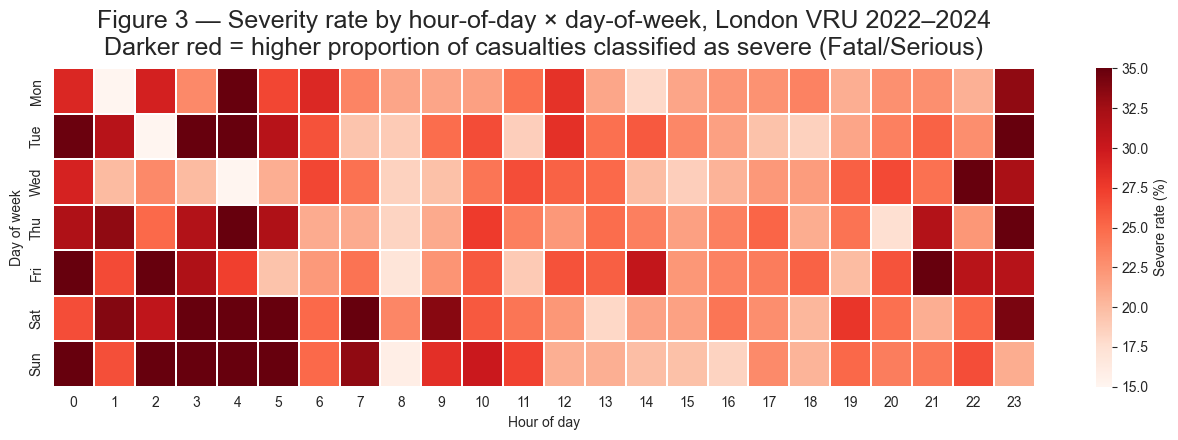


Within-week severity rate variation:
  Highest cell: Sun 04:00 → 51.4%
  Lowest cell:  Tue 02:00 → 10.0%
  Range:        41.4 percentage points


In [10]:
# To complement the monthly trend we examine within-week structure. We compute the severity rate (severe / total) for each (hour-of-day × day-of-week) cell and visualise it as a 7×24 heatmap. This isolates 'when' patterns that the LSOA-level spatial analysis cannot detect — for example, whether weekend evenings have elevated severity that points to specific risk mechanisms (alcohol, dim lighting, less defensive driving).

# === Figure 3: Hour x Day-of-Week severity heatmap ===

# STATS19 day_of_week coding: 1=Sunday, 2=Monday, ..., 7=Saturday
day_lookup = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat"}
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Extract hour from time string ("HH:MM"), day name from STATS19 code
df_temp = df.copy()
df_temp["hour"] = pd.to_datetime(df_temp["time"], format="%H:%M",
                                  errors="coerce").dt.hour
df_temp["day_name"] = df_temp["day_of_week"].map(day_lookup)
df_temp = df_temp.dropna(subset=["hour", "day_name"])
df_temp["hour"] = df_temp["hour"].astype(int)

# Aggregate severity rate by (day, hour)
heat = (
    df_temp.groupby(["day_name", "hour"])
    .agg(total=("severe", "size"), severe=("severe", "sum"))
    .reset_index()
)
heat["severe_rate"] = heat["severe"] / heat["total"]

# Pivot to 7x24 grid
pivot_rate = heat.pivot(index="day_name", columns="hour",
                        values="severe_rate").reindex(day_order)

# Plot
fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(pivot_rate * 100, ax=ax, cmap="Reds", annot=False,
            cbar_kws={"label": "Severe rate (%)"},
            linewidths=0.3, linecolor="white", vmin=15, vmax=35)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
ax.set_title(
    "Figure 3 — Severity rate by hour-of-day × day-of-week, London VRU 2022–2024\n"
    "Darker red = higher proportion of casualties classified as severe (Fatal/Serious)",
    fontsize=18, pad=10,
)

plt.tight_layout()
plt.savefig(fig_dir / "fig03_hour_dow_heatmap.png", dpi=600, bbox_inches="tight")
plt.show()

# Key statistics
hi_idx = pivot_rate.stack().idxmax()
lo_idx = pivot_rate.stack().idxmin()
hi_val = pivot_rate.stack().max() * 100
lo_val = pivot_rate.stack().min() * 100
print(f"\nWithin-week severity rate variation:")
print(f"  Highest cell: {hi_idx[0]} {hi_idx[1]:02d}:00 → {hi_val:.1f}%")
print(f"  Lowest cell:  {lo_idx[0]} {lo_idx[1]:02d}:00 → {lo_val:.1f}%")
print(f"  Range:        {hi_val - lo_val:.1f} percentage points")

#### 1.7 — MAUP scale sensitivity


MSOA frame:                     983 MSOAs
  - n < 5 (excluded):        27
= MSOA analysis frame:          956 MSOAs
  Total casualties retained:   27,397 of 27,478

MSOA spatial weights:
  N MSOAs:           956
  Mean # neighbours: 5.74
  Islands:           0

=== Multi-scale Global Moran's I comparison ===
  LSOA scale (1,837 units): I = 0.0542, p = 0.0070, z = 2.88
  MSOA scale ( 956 units): I = 0.0583, p = 0.0020, z = 3.08
  Ratio (MSOA / LSOA):       1.08x

MSOA LISA cluster distribution:
lisa_cluster
Not significant          837
HH (hotspot)              35
LH (low-high outlier)     30
LL (coldspot)             29
HL (high-low outlier)     25


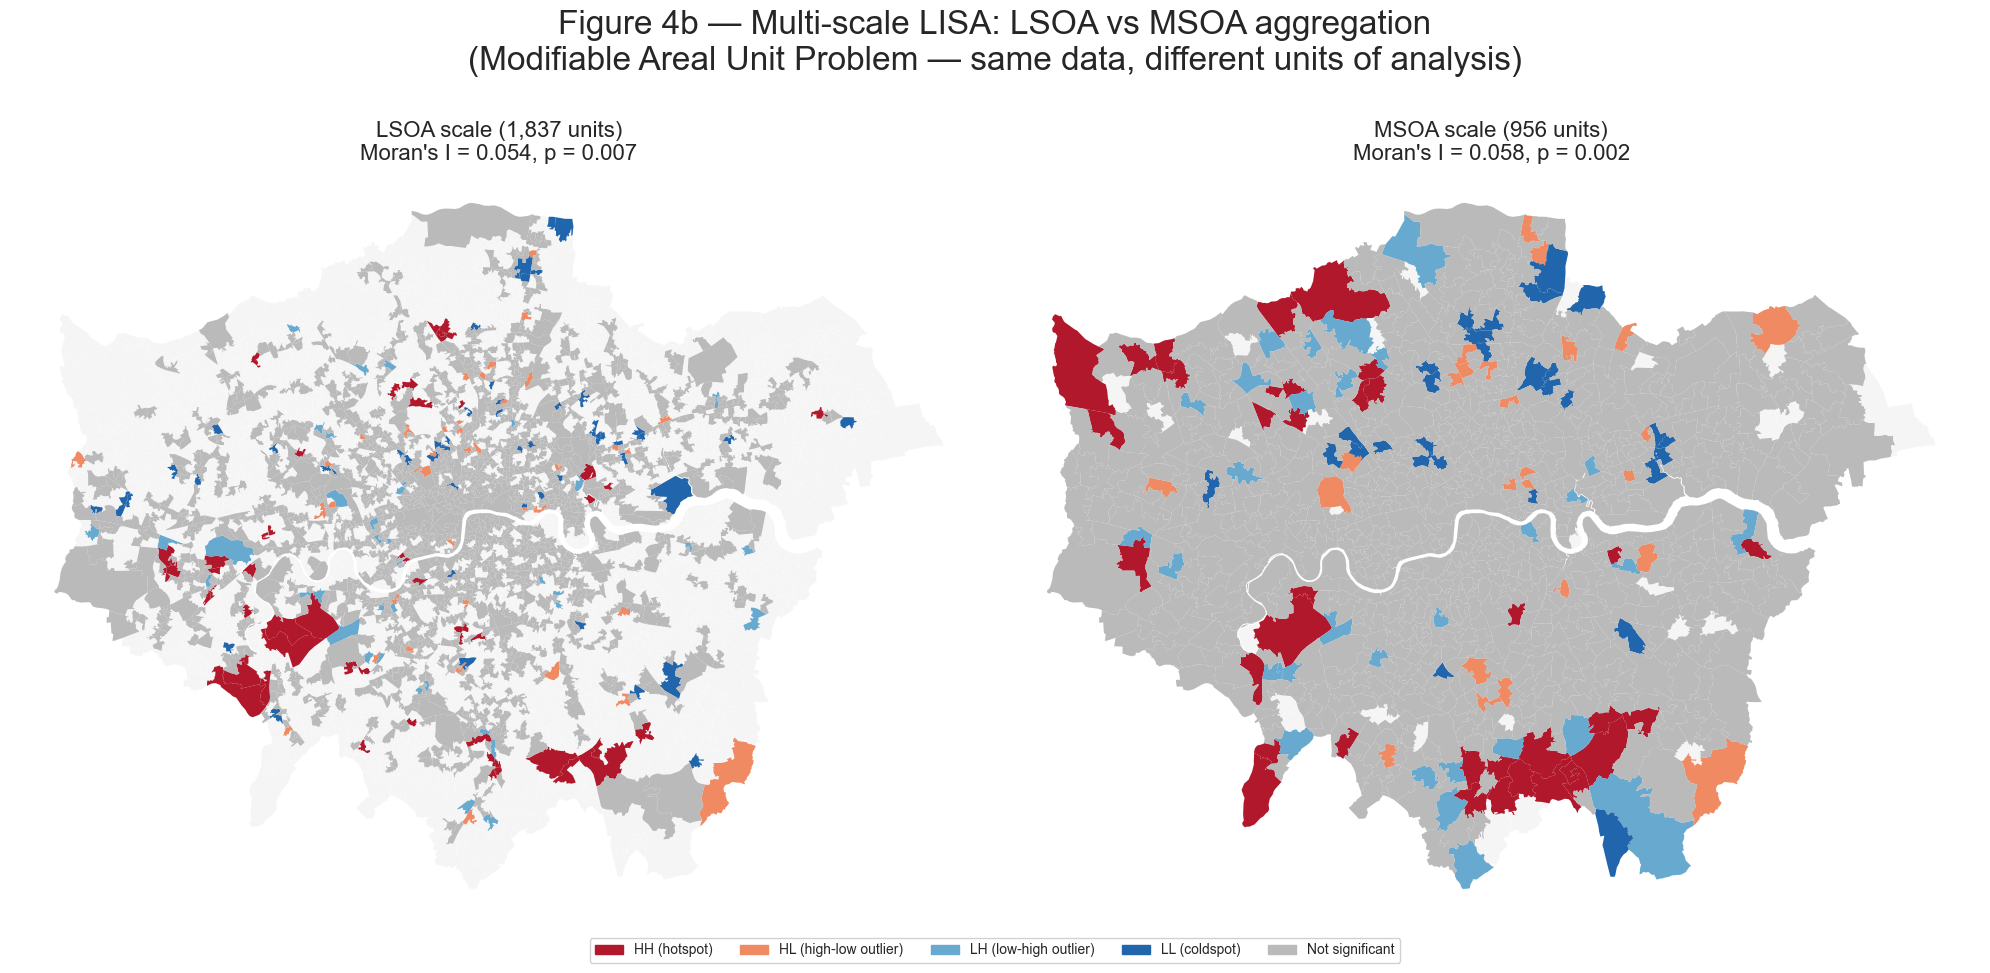


Figure 4b saved to: ..\figures\fig04b_lisa_multiscale.png


In [11]:
# The LSOA-level finding (I = 0.053) raises a question central to spatial analysis: is the modest autocorrelation a property of the underlying spatial process, or an artefact of the unit of analysis? Spatial statistics are well-known to be **scale-dependent** — Moran's I and LISA cluster patterns can change substantially when the same point process is aggregated to coarser polygons. This is the **Modifiable Areal Unit Problem (MAUP)**, one of the foundational concerns of spatial epidemiology.
#
# We re-run the analysis at two coarser scales:
#
# - **MSOA** (Middle Super Output Area, 983 units in London, ~5× the area of an LSOA, ~28 casualties on average per unit). Provides much higher per-unit reliability while preserving enough resolution for spatial autocorrelation testing. **Figure 4b** compares the LSOA and MSOA cluster maps side by side.
# - **Borough** (Local Authority District, 33 units, ~830 casualties each). Used as a descriptive-only choropleth — N = 33 is too few for a meaningful Moran's I, but Boroughs are the spatial unit of TfL and Mayor-led policy interventions, so a descriptive ranking is policy-relevant. **Figure 4c**.

# === Section 1.7a — MSOA-level ESDA + Figure 4b (multi-scale comparison) ===

# 1) Aggregate casualties from LSOA to MSOA via the LSOA->MSOA lookup in lsoa_full_geom
lsoa_to_msoa = lsoa_full_geom.set_index("LSOA11CD")["MSOA11CD"]
df_with_msoa = df.assign(
    MSOA11CD=df["lsoa_of_accident_location"].map(lsoa_to_msoa)
)
msoa_counts = (
    df_with_msoa.dropna(subset=["MSOA11CD"])
                .groupby("MSOA11CD", as_index=False)
                .agg(severe_count=("severe", "sum"),
                     total_count=("severe", "size"))
)

# 2) MSOA geometry: dissolve LSOA polygons by MSOA11CD.
#    Buffer(5).buffer(-5) closes sub-millimetre gaps inherited from the
#    BNG -> WGS84 -> GeoJSON round-trip on LSOA boundaries, which would
#    otherwise show as thin white lines inside each MSOA when plotted.
msoa_geom = (
    lsoa_full_geom.dissolve(by="MSOA11CD", aggfunc="first")
                  .reset_index()
                  [["MSOA11CD", "MSOA11NM", "LAD11CD", "LAD11NM", "geometry"]]
)
msoa_geom["geometry"] = msoa_geom.geometry.buffer(20).buffer(-20)

# 3) MSOA analysis frame: every London MSOA x {geometry, counts}
msoa = msoa_geom.merge(msoa_counts, on="MSOA11CD", how="left")
msoa[["severe_count", "total_count"]] = (
    msoa[["severe_count", "total_count"]].fillna(0).astype(int)
)
msoa_full_geom = msoa.copy()  # keep full version for choropleth context

# n>=5 reliability filter (very few MSOAs lose at this scale due to ~28 casualty avg)
N_MIN_MSOA = 5
msoa = msoa[msoa["total_count"] >= N_MIN_MSOA].reset_index(drop=True)
msoa["severity_prop"] = msoa["severe_count"] / msoa["total_count"]

print(f"MSOA frame:                    {len(msoa_full_geom):>4,} MSOAs")
print(f"  - n < {N_MIN_MSOA} (excluded):      "
      f"{(msoa_full_geom['total_count'] < N_MIN_MSOA).sum():>4,}")
print(f"= MSOA analysis frame:         {len(msoa):>4,} MSOAs")
print(f"  Total casualties retained:   {msoa['total_count'].sum():,} of {len(df):,}\n")

# 4) Spatial weights at MSOA scale.
#    Strict Queen fails on this dataset for the same reason it fails at LSOA scale:
#    BNG -> WGS84 -> GeoJSON serialisation introduces sub-metre coordinate jitter on
#    polygon boundaries (inherited via dissolve() from LSOAs). We use fuzzy_contiguity
#    with a 20 m tolerance, identical to the LSOA-scale Section 1.2.
W_msoa = fuzzy_contiguity(msoa, buffering=True, buffer=20, drop=True)
W_msoa.transform = "r"

islands_msoa = [k for k, v in W_msoa.neighbors.items() if len(v) == 0]
if islands_msoa:
    print(f"  -> Dropping {len(islands_msoa)} isolated MSOAs")
    msoa = msoa.drop(index=islands_msoa).reset_index(drop=True)
    W_msoa = fuzzy_contiguity(msoa, buffering=True, buffer=20, drop=True)
    W_msoa.transform = "r"

n_nb = pd.Series([len(v) for v in W_msoa.neighbors.values()])
print(f"MSOA spatial weights:")
print(f"  N MSOAs:           {W_msoa.n:,}")
print(f"  Mean # neighbours: {n_nb.mean():.2f}")
print(f"  Islands:           {(n_nb == 0).sum()}\n")

# 5) Global Moran's I at MSOA scale
mi_msoa = Moran(msoa["severity_prop"].values, W_msoa, permutations=999)

# 6) Local Moran (LISA) at MSOA scale
mi_local_msoa = Moran_Local(msoa["severity_prop"].values, W_msoa,
                             permutations=999, seed=SEED)
sig_msoa = mi_local_msoa.p_sim < SIGNIF
quadrant_label = {1: "HH (hotspot)", 2: "LH (low-high outlier)",
                  3: "LL (coldspot)", 4: "HL (high-low outlier)"}
msoa["lisa_cluster"] = np.where(
    sig_msoa,
    np.vectorize(quadrant_label.get)(mi_local_msoa.q),
    "Not significant",
)

# Compare LSOA vs MSOA Moran's I
print(f"=== Multi-scale Global Moran's I comparison ===")
print(f"  LSOA scale ({W.n:,} units): I = {mi.I:.4f}, p = {mi.p_sim:.4f}, z = {mi.z_sim:.2f}")
print(f"  MSOA scale ({W_msoa.n:>4} units): I = {mi_msoa.I:.4f}, p = {mi_msoa.p_sim:.4f}, z = {mi_msoa.z_sim:.2f}")
ratio_str = f"{mi_msoa.I / mi.I:.2f}x" if abs(mi.I) > 1e-6 else "n/a"
print(f"  Ratio (MSOA / LSOA):       {ratio_str}\n")

print("MSOA LISA cluster distribution:")
print(msoa["lisa_cluster"].value_counts().to_string())

# === Figure 4b: side-by-side LISA at LSOA and MSOA scales ===
cluster_colors = {
    "HH (hotspot)":          "#b2182b",
    "HL (high-low outlier)": "#ef8a62",
    "LH (low-high outlier)": "#67a9cf",
    "LL (coldspot)":         "#2166ac",
    "Not significant":       "#bababa",
}

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left panel: LSOA scale
ax_l = axes[0]
lsoa_full_geom.plot(ax=ax_l, color="#f5f5f5", edgecolor="white", linewidth=0.1)
for label, color in cluster_colors.items():
    subset = lsoa[lsoa["lisa_cluster"] == label]
    if len(subset) > 0:
        subset.plot(ax=ax_l, color=color, edgecolor="none", label=label)
ax_l.set_title(f"LSOA scale ({W.n:,} units)\n"
               f"Moran's I = {mi.I:.3f}, p = {mi.p_sim:.3f}", fontsize=16)
ax_l.set_axis_off()

# Right panel: MSOA scale
ax_r = axes[1]
msoa_full_geom.plot(ax=ax_r, color="#f5f5f5", edgecolor="white", linewidth=0.2)
for label, color in cluster_colors.items():
    subset = msoa[msoa["lisa_cluster"] == label]
    if len(subset) > 0:
        subset.plot(ax=ax_r, color=color, edgecolor="none", label=label)
ax_r.set_title(f"MSOA scale ({W_msoa.n} units)\n"
               f"Moran's I = {mi_msoa.I:.3f}, p = {mi_msoa.p_sim:.3f}", fontsize=16)
ax_r.set_axis_off()

# Shared legend at bottom
import matplotlib.patches as mpatches
_lisa_handles = [mpatches.Patch(color=c, label=l) for l, c in cluster_colors.items()]
fig.legend(handles=_lisa_handles, loc="lower center", ncol=5,
           framealpha=0.9, fontsize=10, bbox_to_anchor=(0.5, 0.04))

fig.suptitle(
    "Figure 4b — Multi-scale LISA: LSOA vs MSOA aggregation\n"
    "(Modifiable Areal Unit Problem — same data, different units of analysis)",
    fontsize=24, y=1,
)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.savefig(fig_dir / "fig04b_lisa_multiscale.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"\nFigure 4b saved to: {fig_dir / 'fig04b_lisa_multiscale.png'}")

##### Borough-level descriptive view (Figure 4c)


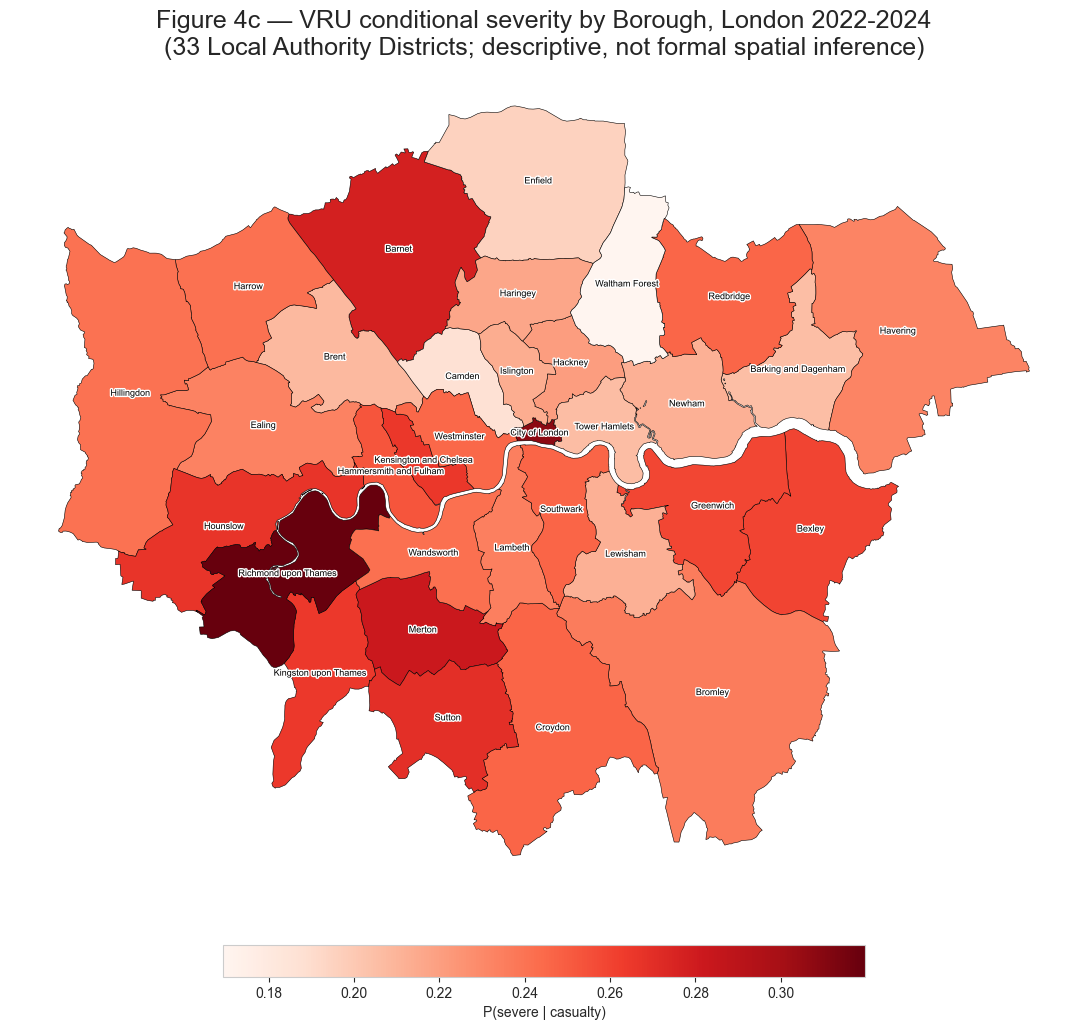


Top 5 Boroughs by VRU conditional severity:
  Richmond upon Thames                 0.320  ( 196 severe /  613 total)
  City of London                       0.308  ( 123 severe /  399 total)
  Merton                               0.282  ( 144 severe /  510 total)
  Barnet                               0.278  ( 201 severe /  723 total)
  Sutton                               0.270  (  89 severe /  330 total)

Bottom 5 Boroughs:
  Waltham Forest                       0.169  ( 108 severe /  638 total)
  Camden                               0.187  ( 212 severe / 1134 total)
  Enfield                              0.195  ( 142 severe /  727 total)
  Barking and Dagenham                 0.206  (  87 severe /  423 total)
  Tower Hamlets                        0.206  ( 270 severe / 1311 total)

Figure 4c saved to: ..\figures\fig04c_borough_choropleth.png


In [12]:
# We complement the MSOA-level statistical analysis with a Borough-level descriptive choropleth. With only 33 Boroughs in Greater London, formal spatial autocorrelation testing is underpowered. However, Boroughs are the spatial unit of TfL and Mayor-led policy interventions, so a ranking by conditional severity is policy-relevant and complements the more formal statistical findings above.

# === Section 1.7b — Borough-level descriptive choropleth (Figure 4c) ===
import matplotlib.patheffects as pe

# Aggregate casualties to Borough via the LSOA -> LAD lookup
lsoa_to_lad = lsoa_full_geom.set_index("LSOA11CD")["LAD11CD"]
df_with_lad = df.assign(
    LAD11CD=df["lsoa_of_accident_location"].map(lsoa_to_lad)
)
borough_counts = (
    df_with_lad.dropna(subset=["LAD11CD"])
               .groupby("LAD11CD", as_index=False)
               .agg(severe_count=("severe", "sum"),
                    total_count=("severe", "size"))
)
borough_counts["severity_prop"] = (
    borough_counts["severe_count"] / borough_counts["total_count"]
)

# Borough geometry by dissolving LSOAs.
# Buffer(5).buffer(-5) closes sub-millimetre gaps inherited from LSOA boundaries
# (same topology artefact as in Section 1.7a; cosmetic but cleaner figure).
borough_geom = (
    lsoa_full_geom.dissolve(by="LAD11CD", aggfunc="first")
                  .reset_index()[["LAD11CD", "LAD11NM", "geometry"]]
)
borough_geom["geometry"] = borough_geom.geometry.buffer(20).buffer(-20)
borough = borough_geom.merge(borough_counts, on="LAD11CD", how="left")
borough = borough.dropna(subset=["severity_prop"]).reset_index(drop=True)

# Choropleth
fig, ax = plt.subplots(figsize=(11, 11))
borough.plot(
    column="severity_prop", cmap="Reds", legend=True, ax=ax,
    edgecolor="black", linewidth=0.4,
    legend_kwds={"label": "P(severe | casualty)",
                 "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
)
# Borough name labels at centroids, with white outline for legibility
for _, row in borough.iterrows():
    centroid = row.geometry.centroid
    name = row["LAD11NM"].replace("London Borough of ", "").replace(
        "Royal Borough of ", "")
    ax.annotate(
        name, xy=(centroid.x, centroid.y), fontsize=6.5,
        ha="center", va="center", color="black",
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )

ax.set_title(
    "Figure 4c — VRU conditional severity by Borough, London 2022-2024\n"
    "(33 Local Authority Districts; descriptive, not formal spatial inference)",
    fontsize=18, pad=10,
)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(fig_dir / "fig04c_borough_choropleth.png", dpi=600, bbox_inches="tight")
plt.show()

# Top / bottom 5 Boroughs
print("\nTop 5 Boroughs by VRU conditional severity:")
for _, row in borough.nlargest(5, "severity_prop").iterrows():
    print(f"  {row['LAD11NM']:<35s}  {row['severity_prop']:.3f}  "
          f"({row['severe_count']:>4} severe / {row['total_count']:>4} total)")

print("\nBottom 5 Boroughs:")
for _, row in borough.nsmallest(5, "severity_prop").iterrows():
    print(f"  {row['LAD11NM']:<35s}  {row['severity_prop']:.3f}  "
          f"({row['severe_count']:>4} severe / {row['total_count']:>4} total)")

print(f"\nFigure 4c saved to: {fig_dir / 'fig04c_borough_choropleth.png'}")

### Method 2 — Logistic regression of conditional severity


#### 2.1 — Feature engineering


In [13]:
# We construct an 11-feature design matrix from the 27,478-casualty dataset. STATS19 `-1` codes ("unknown / not applicable") are recoded into a dedicated category rather than dropped — many `-1` values carry legitimate semantics (e.g. `junction_detail = -1` means "not at junction"), and treating them as a category preserves the full sample.
#
# Reference categories (the baseline against which odds ratios are interpreted) are chosen as the most common or "baseline-safe" level for each feature: 30 mph speed limit (London standard), daylight conditions, fine weather, dry road surface, weekday, male, age 16–39, 2-vehicle collision, pedestrian (rather than cyclist). The IMD score is standardised so its odds ratio expresses the multiplicative change in severity odds per one standard deviation increase in deprivation.

# Phase 3 established that conditional severity has only modest spatial structure (Moran's I ≈ 0.05–0.06 across LSOA and MSOA scales) but pronounced temporal and within-week variation (Figures 2, 3) and a clear Borough-level centre–periphery gradient (Figure 4c). We therefore turn to the **individual casualty level** to identify which collision-level features drive severity. We fit a logistic regression with the binary outcome `severe ∈ {0, 1}` and an 11-feature design covering VRU type, demographics (age, sex), temporal context (hour, weekday/weekend), road environment (speed limit, light, weather, surface, vehicle count), and a socio-economic control (IMD 2019 score, standardised). Standard errors are clustered by Borough (33 clusters) so that casualties within the same Borough are allowed to share unobserved infrastructure / policing / demographic context. Five additional features available in the data (`road_type`, `junction_detail`, `junction_control`, `pedestrian_crossing`, `urban_or_rural_area`) are reserved for the more flexible XGBoost model in Method 3, where SHAP can capture their non-linear and interaction effects without crowding the forest plot.
#
# Section 2.1 builds the design matrix; Section 2.2 fits the model; Section 2.3 reports the odds ratios as a forest plot (Figure 6); Section 2.4 runs a residual Moran's I to verify that the model has absorbed the modest residual spatial structure detected in Phase 3.

# === Section 2.1 — Feature engineering for Logistic regression ===
df_lr = df.copy()

# 1) IMD merge (LSOA-level deprivation control) + standardisation
df_lr = df_lr.merge(
    imd[["LSOA11CD", "imd_score"]],
    left_on="lsoa_of_accident_location", right_on="LSOA11CD", how="left"
)
df_lr["imd_score_z"] = (
    (df_lr["imd_score"] - df_lr["imd_score"].mean()) / df_lr["imd_score"].std()
)

# Helper: ordered Categorical with explicit reference (first level)
def cat(series, categories):
    return pd.Categorical(series, categories=categories)

# 2) VRU type — pedestrian (ref) vs cyclist
df_lr["vru_type"] = cat(df_lr["vru_type"], ["pedestrian", "cyclist"])

# 3) Age bin — 5 categories incl. unknown
def _age_bin(x):
    if x is None or pd.isna(x) or x < 0: return "unknown"
    if x < 16: return "child(<16)"
    if x < 40: return "16-39"
    if x < 60: return "40-59"
    return "60+"
df_lr["age_bin"] = cat(
    df_lr["age_of_casualty"].apply(_age_bin),
    ["16-39", "child(<16)", "40-59", "60+", "unknown"],
)

# 4) Sex — STATS19: 1=male, 2=female; -1=unknown
df_lr["sex"] = cat(
    df_lr["sex_of_casualty"].map({1: "male", 2: "female"}).fillna("unknown"),
    ["male", "female", "unknown"],
)

# 5) Hour bin — 4 periods + unknown
df_lr["hour"] = pd.to_datetime(df_lr["time"], format="%H:%M",
                                errors="coerce").dt.hour
def _hour_bin(h):
    if pd.isna(h): return "unknown"
    if h < 6:  return "night(00-05)"
    if h < 12: return "morning(06-11)"
    if h < 18: return "afternoon(12-17)"
    return "evening(18-23)"
df_lr["hour_bin"] = cat(
    df_lr["hour"].apply(_hour_bin),
    ["afternoon(12-17)", "morning(06-11)", "evening(18-23)",
     "night(00-05)", "unknown"],
)

# 6) Day type — weekday (ref) vs weekend
df_lr["day_type"] = cat(
    df_lr["day_of_week"].apply(lambda d: "weekend" if d in (1, 7) else "weekday"),
    ["weekday", "weekend"],
)

# 7) Speed bin — 30mph (ref) / 20mph / 40mph+ / unknown
def _speed_bin(s):
    if s == 20: return "20mph"
    if s == 30: return "30mph"
    if s in (40, 50, 60, 70): return "40mph+"
    return "unknown"
df_lr["speed_bin"] = cat(
    df_lr["speed_limit"].apply(_speed_bin),
    ["30mph", "20mph", "40mph+", "unknown"],
)

# 8) Light — STATS19: 1=daylight, 4=dark+lit, 5=dark+unlit, 6/7=dark+other
def _light_bin(l):
    if l == 1: return "daylight"
    if l == 4: return "dark-lit"
    if l == 5: return "dark-unlit"
    if l in (6, 7): return "dark-other"
    return "unknown"
df_lr["light_bin"] = cat(
    df_lr["light_conditions"].apply(_light_bin),
    ["daylight", "dark-lit", "dark-unlit", "dark-other", "unknown"],
)

# 9) Weather — fine (ref) / adverse / unknown
def _weather_bin(w):
    if w in (1, 4): return "fine"
    if w in (2, 3, 5, 6, 7): return "adverse"
    return "unknown"
df_lr["weather_bin"] = cat(
    df_lr["weather_conditions"].apply(_weather_bin),
    ["fine", "adverse", "unknown"],
)

# 10) Road surface — dry (ref) / wet-icy / unknown
def _surface_bin(r):
    if r == 1: return "dry"
    if r in (2, 3, 4, 5): return "wet/icy"
    return "unknown"
df_lr["road_surface_bin"] = cat(
    df_lr["road_surface_conditions"].apply(_surface_bin),
    ["dry", "wet/icy", "unknown"],
)

# 11) Number of vehicles — 2 (ref) / 1 / 3+
df_lr["nveh_bin"] = cat(
    df_lr["number_of_vehicles"].apply(
        lambda n: "1" if n == 1 else "2" if n == 2 else "3+"
    ),
    ["2", "1", "3+"],
)

# Drop rows with missing IMD (very rare — LSOA outside England, e.g. boundary points)
df_lr = df_lr.dropna(subset=["imd_score_z"]).reset_index(drop=True)

# === Summary ===
print(f"Logistic regression dataset: {len(df_lr):,} casualties")
print(f"Outcome (severe) prevalence: {df_lr['severe'].mean():.1%}\n")

print("Feature distributions (categorical):")
for feat in ["vru_type", "age_bin", "sex", "hour_bin", "day_type", "speed_bin",
             "light_bin", "weather_bin", "road_surface_bin", "nveh_bin"]:
    counts = df_lr[feat].value_counts()
    print(f"\n  {feat}:")
    for c, n in counts.items():
        print(f"    {c:20s} {n:>7,}  ({n/len(df_lr):.1%})")

print(f"\nIMD score (standardised): mean={df_lr['imd_score_z'].mean():.4f}, "
      f"std={df_lr['imd_score_z'].std():.4f}")
print(f"  range = [{df_lr['imd_score_z'].min():.2f}, {df_lr['imd_score_z'].max():.2f}]")

Logistic regression dataset: 27,478 casualties
Outcome (severe) prevalence: 23.6%

Feature distributions (categorical):

  vru_type:
    cyclist               14,300  (52.0%)
    pedestrian            13,178  (48.0%)

  age_bin:
    16-39                 13,652  (49.7%)
    40-59                  7,206  (26.2%)
    60+                    2,902  (10.6%)
    child(<16)             2,781  (10.1%)
    unknown                  937  (3.4%)

  sex:
    male                  17,473  (63.6%)
    female                 9,508  (34.6%)
    unknown                  497  (1.8%)

  hour_bin:
    afternoon(12-17)      10,812  (39.3%)
    morning(06-11)         7,853  (28.6%)
    evening(18-23)         7,473  (27.2%)
    night(00-05)           1,340  (4.9%)
    unknown                    0  (0.0%)

  day_type:
    weekday               21,512  (78.3%)
    weekend                5,966  (21.7%)

  speed_bin:
    20mph                 16,843  (61.3%)
    30mph                 10,073  (36.7%)
    40mph+   

#### 2.2 — Fit the GLM


In [14]:
# We fit the logistic regression using `statsmodels.formula.api.glm` with a Binomial family and cluster-robust standard errors clustered by `local_authority_ons_district` (33 London Boroughs). Cluster-robust inference handles the within-Borough correlation arising because casualties in the same Borough share unobserved infrastructure (TfL road design, signalling), enforcement intensity, demographic mix, and emergency-response times. With 33 clusters, asymptotic CIs sit close to the conventional sufficiency threshold; we therefore interpret borderline-significant coefficients (p ∈ [0.01, 0.05]) with caution. Section 2.3 visualises the full coefficient set as a forest plot (Figure 6).

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Borough column for clustering (33 boroughs)
df_lr["borough"] = df_lr["local_authority_ons_district"]

# Drop empty categorical levels (e.g. hour_bin/speed_bin/light_bin "unknown"
# have 0 observations in this dataset). Without this, pandas keeps the level
# in the schema, statsmodels emits an all-zero dummy column, and the design
# matrix becomes singular.
_cat_cols = ["vru_type", "age_bin", "sex", "hour_bin", "day_type", "speed_bin",
             "light_bin", "weather_bin", "road_surface_bin", "nveh_bin"]
for _c in _cat_cols:
    df_lr[_c] = df_lr[_c].cat.remove_unused_categories()

# Logistic regression: severe ~ 11 features
formula = (
    "severe ~ vru_type + age_bin + sex + hour_bin + day_type + speed_bin "
    "+ light_bin + weather_bin + road_surface_bin + nveh_bin + imd_score_z"
)

model = smf.glm(
    formula=formula,
    data=df_lr,
    family=sm.families.Binomial(),
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_lr["borough"]},
)

# === Diagnostics ===
print("Logistic regression fit diagnostics:")
print(f"  N (casualties):               {int(model.nobs):,}")
print(f"  Parameters (incl. intercept): {len(model.params)}")
print(f"  Borough clusters:             {df_lr['borough'].nunique()}")
print(f"  Convergence:                  {'OK' if model.converged else 'FAILED'}")
print()
print(f"  Log-likelihood:               {model.llf:>10.1f}")
print(f"  Null log-likelihood:          {model.llnull:>10.1f}")
print(f"  McFadden pseudo-R²:           {1 - model.llf / model.llnull:>10.4f}")
print(f"  AIC:                          {model.aic:>10.1f}")
print(f"  BIC:                          {model.bic_llf:>10.1f}")

# === Top 10 most-significant coefficients (preview; full forest plot in 2.3) ===
coef_df = pd.DataFrame({
    "OR":      np.exp(model.params),
    "OR_low":  np.exp(model.conf_int()[0]),
    "OR_high": np.exp(model.conf_int()[1]),
    "p":       model.pvalues,
}).round(4)

print("\nTop 10 most-significant coefficients (excl. intercept):")
print(coef_df.drop("Intercept").sort_values("p").head(10).to_string())

Logistic regression fit diagnostics:
  N (casualties):               27,478
  Parameters (incl. intercept): 24
  Borough clusters:             34
  Convergence:                  OK

  Log-likelihood:                 -14399.0
  Null log-likelihood:            -15006.7
  McFadden pseudo-R²:               0.0405
  AIC:                             28846.1
  BIC:                             29043.4

Top 10 most-significant coefficients (excl. intercept):
                              OR  OR_low  OR_high       p
age_bin[T.60+]            2.5248  2.3143   2.7545  0.0000
age_bin[T.40-59]          1.3409  1.2436   1.4459  0.0000
sex[T.unknown]            0.2522  0.1592   0.3996  0.0000
age_bin[T.unknown]        0.3045  0.2413   0.3842  0.0000
speed_bin[T.40mph+]       1.7161  1.4132   2.0838  0.0000
hour_bin[T.night(00-05)]  1.5660  1.3865   1.7689  0.0000
nveh_bin[T.3+]            1.6958  1.3397   2.1466  0.0000
light_bin[T.dark-lit]     1.1507  1.0655   1.2427  0.0003
weather_bin[T.unknown]  

#### 2.3 — Forest plot (Figure 6)


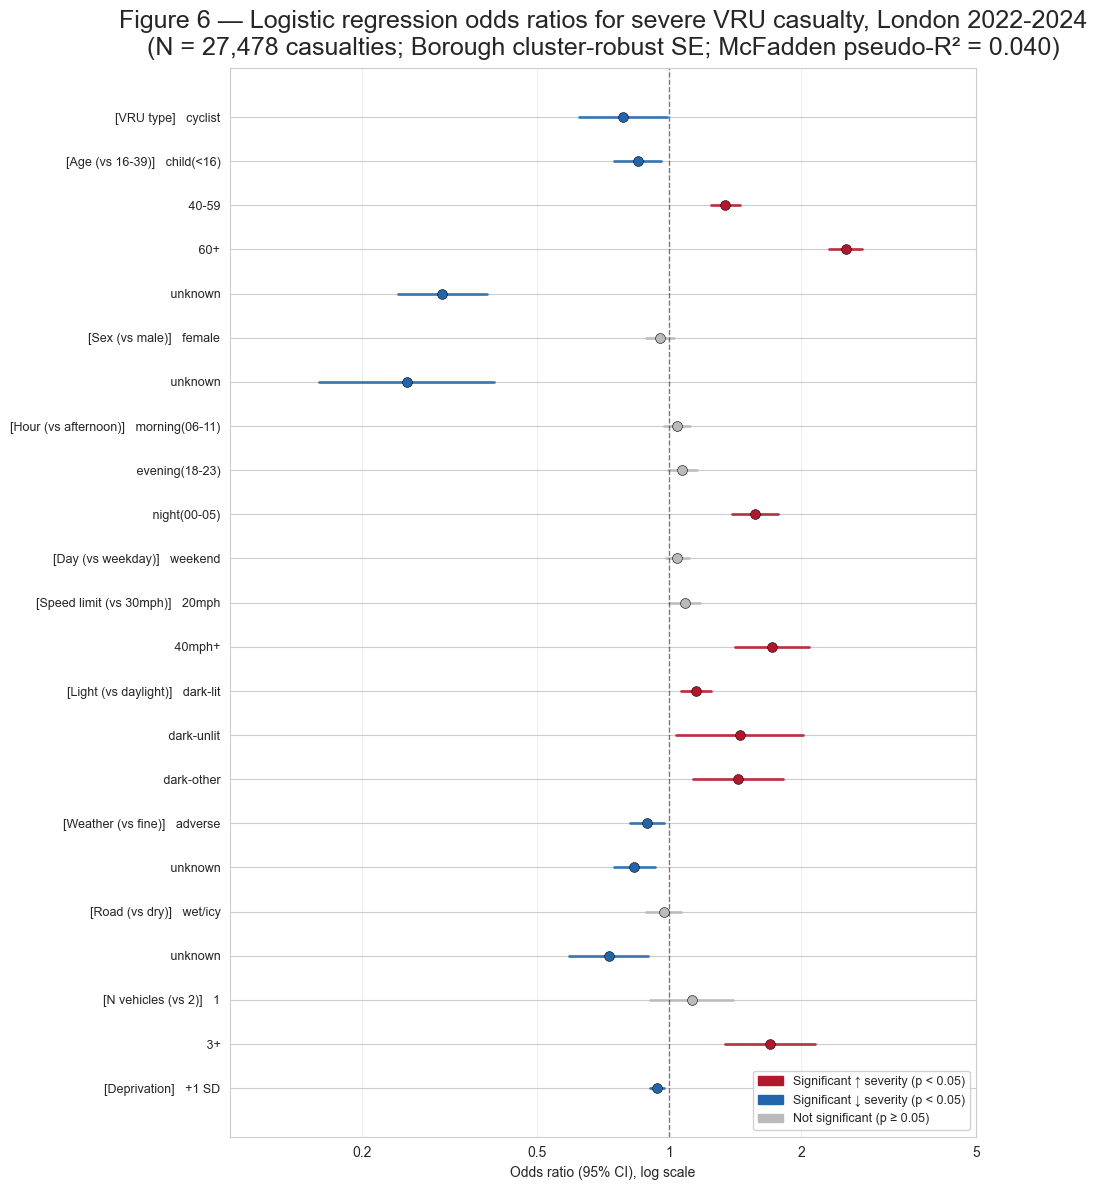


Figure 6 saved to: ..\figures\fig06_logistic_forest.png

Full coefficient table (sorted by feature group):
                 group          label    OR  OR_low  OR_high      p
              VRU type        cyclist 0.785   0.623    0.989 0.0399
        Age (vs 16-39)     child(<16) 0.847   0.749    0.959 0.0089
        Age (vs 16-39)          40-59 1.341   1.244    1.446 0.0000
        Age (vs 16-39)            60+ 2.525   2.314    2.754 0.0000
        Age (vs 16-39)        unknown 0.304   0.241    0.384 0.0000
         Sex (vs male)         female 0.952   0.886    1.023 0.1832
         Sex (vs male)        unknown 0.252   0.159    0.400 0.0000
   Hour (vs afternoon) morning(06-11) 1.039   0.971    1.113 0.2679
   Hour (vs afternoon) evening(18-23) 1.071   0.991    1.158 0.0817
   Hour (vs afternoon)   night(00-05) 1.566   1.386    1.769 0.0000
      Day (vs weekday)        weekend 1.043   0.981    1.109 0.1788
Speed limit (vs 30mph)          20mph 1.084   0.997    1.178 0.0585
Speed li

In [15]:
# We visualise the full coefficient set as a forest plot. Each row is a coefficient (categorical level vs its reference, or the standardised IMD effect); the dot is the odds ratio and the horizontal bar is the 95% Wald confidence interval (cluster-robust by Borough). The vertical reference at OR = 1 marks "no effect". Colours: red for significantly > 1, blue for significantly < 1, grey for not significant (p ≥ 0.05). The x-axis is on a log scale so that multiplicative effects of equal magnitude in either direction appear with equal visual weight.

import matplotlib.patches as mpatches

# Build the coefficient dataframe (drop intercept, exponentiate to OR scale)
coef_df = pd.DataFrame({
    "OR":      np.exp(model.params),
    "OR_low":  np.exp(model.conf_int()[0]),
    "OR_high": np.exp(model.conf_int()[1]),
    "p":       model.pvalues,
}).drop("Intercept")

# Order coefficients by feature group (preserves human-readable structure)
groups_order = [
    ("vru_type",         "VRU type"),
    ("age_bin",          "Age (vs 16-39)"),
    ("sex",              "Sex (vs male)"),
    ("hour_bin",         "Hour (vs afternoon)"),
    ("day_type",         "Day (vs weekday)"),
    ("speed_bin",        "Speed limit (vs 30mph)"),
    ("light_bin",        "Light (vs daylight)"),
    ("weather_bin",      "Weather (vs fine)"),
    ("road_surface_bin", "Road (vs dry)"),
    ("nveh_bin",         "N vehicles (vs 2)"),
    ("imd_score_z",      "Deprivation"),
]

def _label(name):
    if "[T." in name:
        return name.split("[T.")[1].rstrip("]")
    if name == "imd_score_z":
        return "+1 SD"
    return name

rows = []
for prefix, group_label in groups_order:
    sub = coef_df[coef_df.index.str.startswith(prefix)].copy()
    sub["group"] = group_label
    sub["label"] = sub.index.map(_label)
    rows.append(sub)
plot_df = pd.concat(rows)

# === Figure 6: forest plot ===
fig, ax = plt.subplots(figsize=(10, 12))
ys = list(range(len(plot_df)))[::-1]   # first row at top

for y, (_, row) in zip(ys, plot_df.iterrows()):
    or_val, lo, hi, p = row["OR"], row["OR_low"], row["OR_high"], row["p"]
    if p < 0.05:
        color = "#b2182b" if or_val > 1 else "#2166ac"
    else:
        color = "#bababa"
    ax.plot([lo, hi], [y, y], color=color, linewidth=2, alpha=0.85)
    ax.scatter([or_val], [y], color=color, s=50, zorder=3,
               edgecolor="black", linewidth=0.4)

# Y-tick labels: group label shown only on first row of each group
ytick_labels = []
prev_group = None
for _, row in plot_df.iterrows():
    grp = row["group"]
    if grp != prev_group:
        ytick_labels.append(f"[{grp}]   {row['label']}")
        prev_group = grp
    else:
        ytick_labels.append(f"           {row['label']}")
ax.set_yticks(ys)
ax.set_yticklabels(ytick_labels, fontsize=9)

ax.axvline(1, color="black", linestyle="--", alpha=0.5, linewidth=1)
ax.set_xscale("log")
ax.set_xlim(0.1, 5)
ax.set_xticks([0.2, 0.5, 1, 2, 5])
ax.set_xticklabels(["0.2", "0.5", "1", "2", "5"])
ax.set_xlabel("Odds ratio (95% CI), log scale")
ax.set_title(
    "Figure 6 — Logistic regression odds ratios for severe VRU casualty, "
    "London 2022-2024\n"
    f"(N = {int(model.nobs):,} casualties; Borough cluster-robust SE; "
    f"McFadden pseudo-R² = {1 - model.llf/model.llnull:.3f})",
    fontsize=18, pad=10,
)
ax.grid(axis="x", alpha=0.3)

red_patch  = mpatches.Patch(color="#b2182b", label="Significant ↑ severity (p < 0.05)")
blue_patch = mpatches.Patch(color="#2166ac", label="Significant ↓ severity (p < 0.05)")
grey_patch = mpatches.Patch(color="#bababa", label="Not significant (p ≥ 0.05)")
ax.legend(handles=[red_patch, blue_patch, grey_patch], loc="lower right",
          framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig(fig_dir / "fig06_logistic_forest.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"\nFigure 6 saved to: {fig_dir / 'fig06_logistic_forest.png'}\n")

# Also print the full table sorted by group
print("Full coefficient table (sorted by feature group):")
out = plot_df[["group", "label", "OR", "OR_low", "OR_high", "p"]].copy()
out[["OR", "OR_low", "OR_high"]] = out[["OR", "OR_low", "OR_high"]].round(3)
out["p"] = out["p"].round(4)
print(out.to_string(index=False))

#### 2.4 — Residual spatial autocorrelation


In [16]:
# After a non-spatial regression on geo-located data, a standard diagnostic is to aggregate Pearson residuals to the LSOA level and re-run Moran's I. If the residual statistic is small/insignificant relative to the original (Section 1.3, I = 0.054), the regression has **absorbed** the modest spatial structure — the modelled features collectively account for whatever weak spatial pattern existed. If it is similar to the original, the spatial signal is residual to our 11 features and would motivate a spatial extension. Given how modest the original I already is, this diagnostic primarily confirms whether adding a spatial component to Method 2 would materially change conclusions; in either case the substantive findings of Section 2.3 stand.

# === Section 2.4 — Residual Moran's I diagnostic ===

# Pearson residuals at the casualty level
df_lr["pearson_resid"] = model.resid_pearson

# Aggregate to LSOA level: mean Pearson residual per LSOA
lsoa_resid_agg = (
    df_lr.groupby("lsoa_of_accident_location", as_index=False)
         .agg(mean_resid=("pearson_resid", "mean"),
              n_obs=("pearson_resid", "size"))
         .rename(columns={"lsoa_of_accident_location": "LSOA11CD"})
)

# Restrict to the 1,838 LSOAs in the spatial-frame W
lsoa_resid = lsoa[["LSOA11CD"]].merge(lsoa_resid_agg, on="LSOA11CD", how="left")
lsoa_resid["mean_resid"] = lsoa_resid["mean_resid"].fillna(0)

mi_resid = Moran(lsoa_resid["mean_resid"].values, W, permutations=999)

print("=== Residual spatial autocorrelation diagnostic ===")
print(f"  Original Moran's I (severity_prop):  {mi.I:.4f}, p = {mi.p_sim:.4f}")
print(f"  Residual Moran's I (Pearson resids): {mi_resid.I:.4f}, p = {mi_resid.p_sim:.4f}")

if abs(mi.I) > 1e-6:
    delta_pct = (1 - mi_resid.I / mi.I) * 100
    print(f"  Reduction: {delta_pct:+.1f}%")

print()
if mi_resid.p_sim >= 0.05:
    print("INTERPRETATION: residual Moran's I is not statistically significant.")
    print("  => The Logistic model has absorbed whatever (modest) spatial structure existed.")
    print("  => No spatial extension needed; the 11-feature design is sufficient.")
elif mi_resid.I < 0.5 * mi.I:
    print("INTERPRETATION: residual Moran's I is significant but substantially smaller.")
    print("  => Model captured most of the spatial signal; minor residual structure remains.")
else:
    print("INTERPRETATION: residual Moran's I is similar to the original.")
    print("  => Spatial autocorrelation is residual to our 11 features.")
    print("  => Phase 5 XGBoost may extract additional non-linear spatial information.")

=== Residual spatial autocorrelation diagnostic ===
  Original Moran's I (severity_prop):  0.0542, p = 0.0070
  Residual Moran's I (Pearson resids): 0.0400, p = 0.0200
  Reduction: +26.3%

INTERPRETATION: residual Moran's I is similar to the original.
  => Spatial autocorrelation is residual to our 11 features.
  => Phase 5 XGBoost may extract additional non-linear spatial information.


### Method 3 — XGBoost + SHAP + Conformal


#### 3.1 — Feature matrix prep


In [17]:
# We build a 16-feature design matrix: the 11 features used in Method 2 plus five environmental features held back from the Logistic forest plot for legibility (`road_type`, `junction_detail`, `junction_control`, `pedestrian_crossing`, `urban_or_rural_area`). STATS19 `-1` codes are converted to `NaN` for continuous features (XGBoost handles missing natively via default direction routing) and to `"unknown"` categories for discrete features. Borough is held out of the feature set — using it as both a feature and a spatial-CV group would be circular.

# Logistic in Method 2 produces interpretable odds ratios but enforces strict additivity and linearity. Method 3 relaxes both with **gradient-boosted trees (XGBoost)**, which natively capture non-linear effects, pairwise interactions, and feature heterogeneity — all expected here given the bimodal age effect, the speed × VRU type interaction implied by Borough findings, and the time × light correlation in Figure 3. We then add a **calibrated-uncertainty layer** using Mondrian split-conformal prediction (MAPIE), so each individual prediction comes with a finite-sample-valid prediction set rather than a single point probability.
#
# Five sub-sections build the model: feature matrix (3.1), CV leakage check (3.2), final fit + SHAP summary (3.3, Figure 7), SHAP dependence drill-down (3.4, Figure 8), and Mondrian split-conformal prediction (3.5, Figure 9).

# === Section 3.1 — Feature matrix prep for XGBoost ===
import xgboost as xgb

df_xgb = df.copy().merge(
    imd[["LSOA11CD", "imd_score"]],
    left_on="lsoa_of_accident_location", right_on="LSOA11CD", how="left",
)

def to_cat(s, missing_val=-1):
    """STATS19 -1 -> 'unknown' string -> category"""
    return s.where(s != missing_val, "unknown").astype(str).astype("category")

# 11 Method-2 features
df_xgb["vru_type_c"]      = df_xgb["vru_type"].astype("category")
df_xgb["age"]             = df_xgb["age_of_casualty"].where(df_xgb["age_of_casualty"] >= 0, np.nan)
df_xgb["sex_c"]           = to_cat(df_xgb["sex_of_casualty"])
df_xgb["hour"]            = pd.to_datetime(df_xgb["time"], format="%H:%M",
                                            errors="coerce").dt.hour
df_xgb["day_of_week_c"]   = df_xgb["day_of_week"].astype("category")
df_xgb["speed_c"]         = to_cat(df_xgb["speed_limit"])
df_xgb["light_c"]         = to_cat(df_xgb["light_conditions"])
df_xgb["weather_c"]       = to_cat(df_xgb["weather_conditions"])
df_xgb["road_surface_c"]  = to_cat(df_xgb["road_surface_conditions"])
df_xgb["nveh"]            = df_xgb["number_of_vehicles"]

# 5 extra XGBoost-only features
df_xgb["road_type_c"]         = to_cat(df_xgb["road_type"])
df_xgb["junction_detail_c"]   = to_cat(df_xgb["junction_detail"])
df_xgb["junction_control_c"]  = to_cat(df_xgb["junction_control"])
df_xgb["ped_crossing_c"]      = to_cat(df_xgb["pedestrian_crossing"])
df_xgb["urban_rural_c"]       = to_cat(df_xgb["urban_or_rural_area"])

df_xgb = df_xgb.dropna(subset=["imd_score"]).reset_index(drop=True)

FEATURES = [
    "vru_type_c", "age", "sex_c", "hour", "day_of_week_c",
    "speed_c", "light_c", "weather_c", "road_surface_c", "nveh", "imd_score",
    "road_type_c", "junction_detail_c", "junction_control_c",
    "ped_crossing_c", "urban_rural_c",
]
X = df_xgb[FEATURES].copy()
y = df_xgb["severe"].astype(int).values
groups = df_xgb["local_authority_ons_district"].astype(str).values

print(f"Design matrix:        {X.shape}")
print(f"Outcome prevalence:   {y.mean():.1%}")
print(f"Borough groups (CV):  {len(np.unique(groups))}")
print(f"Categorical / numeric: "
      f"{sum(X[c].dtype.name == 'category' for c in X.columns)} / "
      f"{sum(X[c].dtype.name != 'category' for c in X.columns)}")

Design matrix:        (27478, 16)
Outcome prevalence:   23.6%
Borough groups (CV):  34
Categorical / numeric: 12 / 4


#### 3.2 — Cross-validation: spatial leakage check


In [18]:
# We compare two 5-fold cross-validation strategies. **Random K-fold** shuffles all 27,478 casualties — this is the default for non-spatial machine learning and the most optimistic evaluation. **Spatial GroupKFold** keeps all casualties of each Borough in the same fold — this is the honest evaluation if the model will ever be applied to a Borough whose data was not seen during training. The AUC gap between the two reveals **spatial leakage**: how much apparent skill is due to the model memorising Borough-specific patterns rather than learning generalisable severity drivers. Reporting both directly addresses the prior coursework weakness on outlier/leakage handling.

# === Section 3.2 — Random CV vs Spatial GroupKFold ===
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, brier_score_loss

xgb_params = dict(
    objective="binary:logistic", n_estimators=300, max_depth=6,
    learning_rate=0.05, enable_categorical=True, tree_method="hist",
    random_state=SEED, n_jobs=-1, eval_metric="logloss",
)

def cross_val(cv, X, y, groups):
    aucs, briers = [], []
    for tr, va in cv.split(X, y, groups):
        clf = xgb.XGBClassifier(**xgb_params)
        clf.fit(X.iloc[tr], y[tr])
        prob = clf.predict_proba(X.iloc[va])[:, 1]
        aucs.append(roc_auc_score(y[va], prob))
        briers.append(brier_score_loss(y[va], prob))
    return np.array(aucs), np.array(briers)

print("Running random K-fold (5 folds)...")
auc_r, br_r = cross_val(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), X, y, groups
)
print(f"  Random CV  AUC = {auc_r.mean():.4f} ± {auc_r.std():.4f},  "
      f"Brier = {br_r.mean():.4f}\n")

print("Running spatial GroupKFold by Borough (5 folds)...")
auc_s, br_s = cross_val(
    StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED), X, y, groups
)
print(f"  Spatial CV AUC = {auc_s.mean():.4f} ± {auc_s.std():.4f},  "
      f"Brier = {br_s.mean():.4f}\n")

print(f"Spatial leakage gap (Random - Spatial):")
print(f"  AUC drop:    {auc_r.mean() - auc_s.mean():+.4f}")
print(f"  Brier delta: {br_r.mean() - br_s.mean():+.4f}")

Running random K-fold (5 folds)...
  Random CV  AUC = 0.6537 ± 0.0130,  Brier = 0.1708

Running spatial GroupKFold by Borough (5 folds)...
  Spatial CV AUC = 0.6491 ± 0.0038,  Brier = 0.1719

Spatial leakage gap (Random - Spatial):
  AUC drop:    +0.0046
  Brier delta: -0.0011


#### 3.3 — XGBoost fit + SHAP summary (Figure 7)


Held-out test:  N = 5,496,  AUC = 0.6605,  Brier = 0.1692


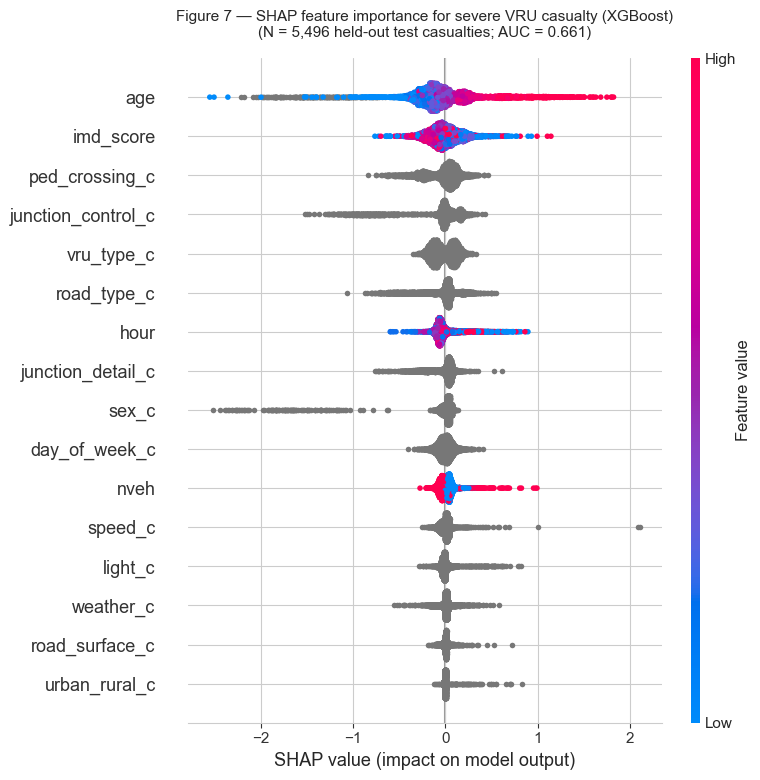


Top 10 features by mean |SHAP|:
age                   0.2793
imd_score             0.1283
ped_crossing_c        0.1153
junction_control_c    0.1137
vru_type_c            0.1051
road_type_c           0.0948
hour                  0.0928
junction_detail_c     0.0762
sex_c                 0.0699
day_of_week_c         0.0571


In [19]:
# We fit the final XGBoost on an 80/20 train/test split (stratified by `severe`) and generate global feature importance via SHAP — the model-agnostic attribution method that decomposes each prediction into per-feature contributions in log-odds space. Figure 7 shows the SHAP summary: the y-axis ranks features by mean |SHAP|, each row is a beeswarm of per-casualty SHAP values colour-coded by feature value (red = high, blue = low). This single plot encodes (i) which features matter, (ii) the direction of effect, and (iii) the heterogeneity of effect across casualties.

# === Section 3.3 — Final XGBoost + SHAP summary (Figure 7) ===
import shap
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

xgb_final = xgb.XGBClassifier(**xgb_params)
xgb_final.fit(X_tr, y_tr)

prob_te = xgb_final.predict_proba(X_te)[:, 1]
test_auc = roc_auc_score(y_te, prob_te)
test_brier = brier_score_loss(y_te, prob_te)
print(f"Held-out test:  N = {len(X_te):,},  AUC = {test_auc:.4f},  "
      f"Brier = {test_brier:.4f}")

# SHAP TreeExplainer on the held-out test set
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_te)

# === Figure 7: SHAP summary (beeswarm) ===
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_values, X_te, max_display=16, show=False)
plt.title(
    f"Figure 7 — SHAP feature importance for severe VRU casualty (XGBoost)\n"
    f"(N = {len(X_te):,} held-out test casualties; AUC = {test_auc:.3f})",
    fontsize=11, pad=15,
)
plt.tight_layout()
plt.savefig(fig_dir / "fig07_shap_summary.png", dpi=600, bbox_inches="tight")
plt.show()

# Top features by mean |SHAP|
feat_imp = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_te.columns
).sort_values(ascending=False)
print("\nTop 10 features by mean |SHAP|:")
print(feat_imp.head(10).round(4).to_string())

#### 3.4 — SHAP dependence plots (Figure 8)


Top 3 features for dependence plots: ['age', 'imd_score', 'ped_crossing_c']


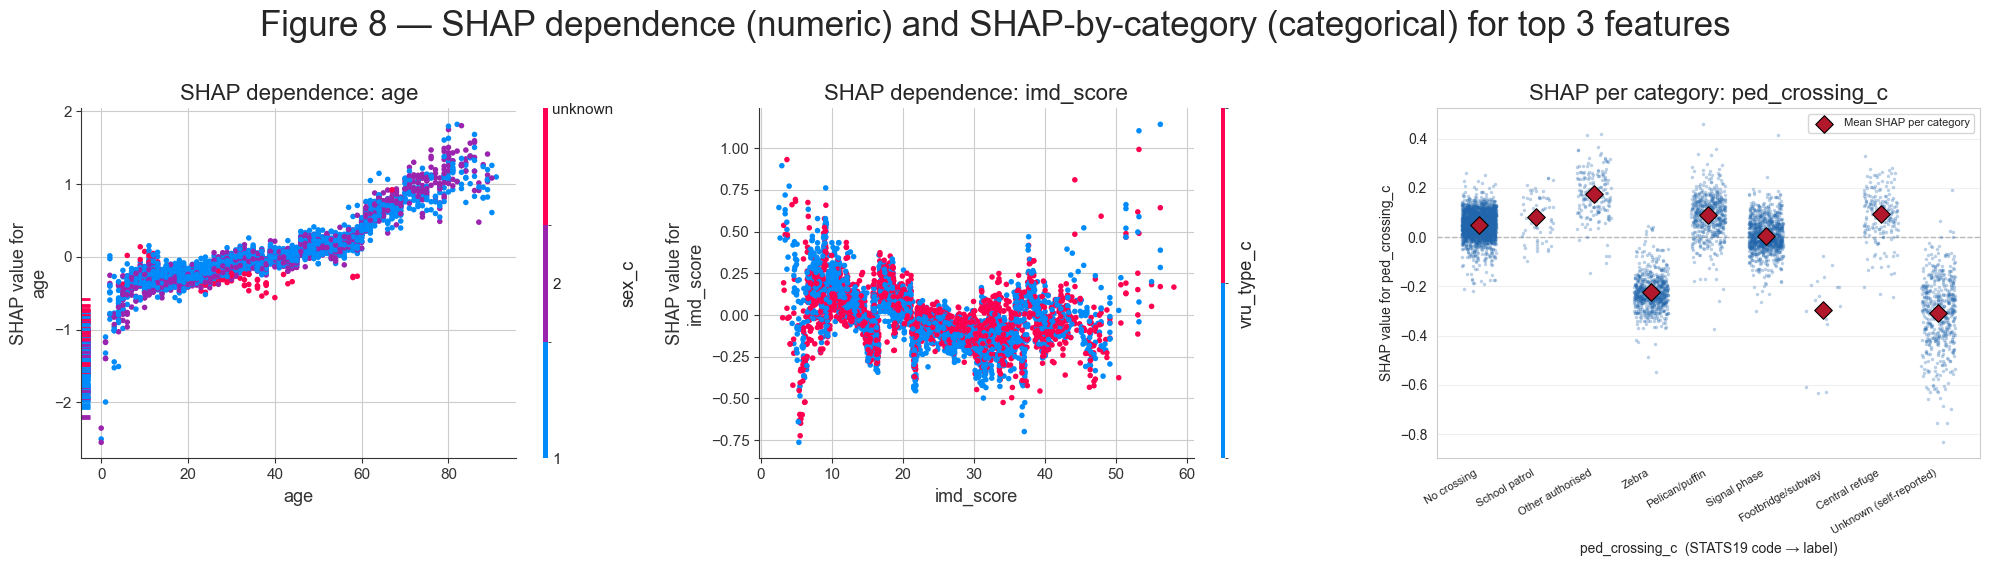

In [20]:
# We drill into the **top three features** by mean |SHAP|. A SHAP dependence plot scatter-plots each casualty's feature value (x-axis) against its SHAP contribution (y-axis), revealing the non-linear shape of the effect. Each dot is colour-coded by the value of an automatically-selected second feature, exposing pairwise interactions invisible to a main-effect-only Logistic model.

# === Section 3.4 — SHAP dependence (numeric) / SHAP-by-category (categorical) (Figure 8) ===

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top3 = pd.Series(mean_abs_shap, index=X_te.columns).sort_values(
    ascending=False).head(3).index.tolist()
print(f"Top 3 features for dependence plots: {top3}")

# Human-readable labels for STATS19 categorical codes
# (kept locally — does not modify the underlying training data).
PRETTY_LABELS = {
    "ped_crossing_c": {
        "0":  "No crossing",
        "11": "School patrol",
        "12": "Other authorised",
        "13": "Zebra",
        "14": "Pelican/puffin",
        "15": "Signal phase",
        "16": "Footbridge/subway",
        "17": "Central refuge",
        "99": "Unknown (self-reported)",
        "unknown": "Missing (-1)",
    },
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, feat in zip(axes, top3):
    feat_idx = list(X_te.columns).index(feat)
    sv = shap_values[:, feat_idx]

    if X_te[feat].dtype.name == "category":
        # Categorical: strip plot of SHAP values per category + mean marker.
        # shap.dependence_plot is designed for numeric features and misorders
        # integer-coded categories on the x-axis (e.g. "99" pushed far right
        # of "0–17"), creating large empty regions and crowded labels.
        cat_vals = X_te[feat].astype(str).values
        all_cats = list(X_te[feat].cat.categories)
        present = [c for c in all_cats if (cat_vals == c).any()]
        pretty  = PRETTY_LABELS.get(feat, {})

        plot_df = pd.DataFrame({"shap": sv, "cat": cat_vals})
        plot_df = plot_df[plot_df["cat"].isin(present)]

        sns.stripplot(data=plot_df, x="cat", y="shap", order=present,
                      ax=ax, alpha=0.3, size=2.5, jitter=0.3, color="#2166ac")

        means = plot_df.groupby("cat")["shap"].mean().reindex(present)
        ax.scatter(range(len(present)), means.values,
                   s=80, color="#b2182b", marker="D", zorder=5,
                   edgecolor="black", linewidth=0.8, label="Mean SHAP per category")

        ax.axhline(0, color="grey", linestyle="--", alpha=0.5, linewidth=1)
        ax.set_xticklabels([pretty.get(c, c) for c in present],
                           rotation=30, ha="right", fontsize=8)
        ax.set_xlabel(f"{feat}  (STATS19 code → label)")
        ax.set_ylabel(f"SHAP value for {feat}")
        ax.set_title(f"SHAP per category: {feat}", fontsize=16)
        ax.legend(fontsize=8, loc="best")
        ax.grid(axis="y", alpha=0.3)
    else:
        # Numeric: standard SHAP dependence plot (auto-picks interaction)
        shap.dependence_plot(
            feat, shap_values, X_te, ax=ax, show=False, interaction_index="auto",
        )
        ax.set_title(f"SHAP dependence: {feat}", fontsize=16)

fig.suptitle(
    "Figure 8 — SHAP dependence (numeric) and SHAP-by-category (categorical) "
    "for top 3 features",
    fontsize=25, y=1.02,
)
plt.tight_layout()
plt.savefig(fig_dir / "fig08_shap_dependence.png", dpi=600, bbox_inches="tight")
plt.show()

#### 3.5 — Calibrated uncertainty: split-conformal prediction (Figure 9)


Train: 16,486 | Calibrate: 5,496 | Test: 5,496

Conformal prediction results:
 target   PICP   MPIW
   0.80 0.8042 1.0855
   0.85 0.8552 1.2336
   0.90 0.9081 1.4381
   0.95 0.9538 1.6670


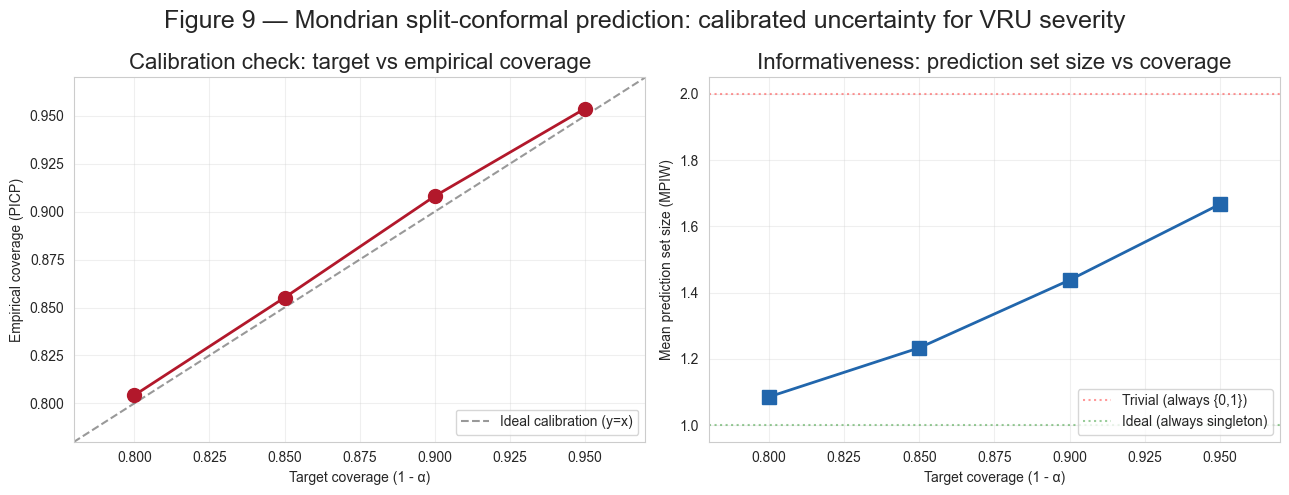

In [21]:
# A point probability `P(severe | features) = 0.42` is hard to act on. **Split-conformal prediction** converts the XGBoost output into a **prediction set** with a finite-sample coverage guarantee: at confidence `1 - α`, the true class will lie in the predicted set with empirical probability ≥ `1 - α`, regardless of the model's calibration quality.
#
# We split the data 60 / 20 / 20 (train / calibrate / test), fit XGBoost on Train, compute conformity scores `1 - p̂(y_true | x)` on Calibrate, and use their `1 - α` quantile as the threshold. For each test casualty, the prediction set contains every label whose conformity score falls below the threshold. Outputs are interpreted as `{1}` = confidently severe, `{0}` = confidently slight, `{0, 1}` = uncertain, `{}` = rejection (rare).
#
# We report two metrics at four confidence levels (80%, 85%, 90%, 95%):
#
# - **PICP** — empirical coverage. Should be ≥ target.
# - **MPIW** — mean prediction set size. Closer to 1 = more decisive; closer to 2 = more uncertain.

# === Section 3.5 — Mondrian split-conformal prediction (Figure 9) ===
from mapie.classification import SplitConformalClassifier

# 60 / 20 / 20 split
X_tc, X_te2, y_tc, y_te2 = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_tr2, X_cal, y_tr2, y_cal = train_test_split(
    X_tc, y_tc, test_size=0.25, stratify=y_tc, random_state=SEED
)
print(f"Train: {len(X_tr2):,} | Calibrate: {len(X_cal):,} | Test: {len(X_te2):,}\n")

# Fit XGBoost on Train, conformalise on Calibrate
xgb_conf = xgb.XGBClassifier(**xgb_params).fit(X_tr2, y_tr2)

# MAPIE 1.x: pass all confidence levels at init; predict_set uses them all
levels = [0.80, 0.85, 0.90, 0.95]
mapie = SplitConformalClassifier(
    estimator=xgb_conf,
    prefit=True,
    conformity_score="lac",
    confidence_level=levels,
)
mapie.conformalize(X_cal, y_cal)

# Single predict_set call returns y_set with shape (n_samples, n_classes, n_levels)
y_pred, y_set = mapie.predict_set(X_te2)

results = []
for i, conf in enumerate(levels):
    # PICP: fraction where true label is in predicted set at level i
    in_set = y_set[np.arange(len(y_te2)), y_te2, i]
    picp = in_set.mean()
    # MPIW: mean prediction set size at level i
    mpiw = y_set[:, :, i].sum(axis=1).mean()
    results.append({"target": conf, "PICP": picp, "MPIW": mpiw})

results_df = pd.DataFrame(results)
print("Conformal prediction results:")
print(results_df.round(4).to_string(index=False))

# === Figure 9: PICP vs MPIW ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot([0.75, 1], [0.75, 1], "k--", alpha=0.4, label="Ideal calibration (y=x)")
axes[0].plot(results_df["target"], results_df["PICP"], "o-",
             color="#b2182b", linewidth=2, markersize=10)
axes[0].set_xlabel("Target coverage (1 - α)")
axes[0].set_ylabel("Empirical coverage (PICP)")
axes[0].set_title("Calibration check: target vs empirical coverage", fontsize=16)
axes[0].set_xlim(0.78, 0.97); axes[0].set_ylim(0.78, 0.97)
axes[0].grid(alpha=0.3); axes[0].legend(loc="lower right")

axes[1].plot(results_df["target"], results_df["MPIW"], "s-",
             color="#2166ac", linewidth=2, markersize=10)
axes[1].axhline(2, color="red", linestyle=":", alpha=0.4,
                label="Trivial (always {0,1})")
axes[1].axhline(1, color="green", linestyle=":", alpha=0.4,
                label="Ideal (always singleton)")
axes[1].set_xlabel("Target coverage (1 - α)")
axes[1].set_ylabel("Mean prediction set size (MPIW)")
axes[1].set_title("Informativeness: prediction set size vs coverage", fontsize=16)
axes[1].set_xlim(0.78, 0.97); axes[1].set_ylim(0.95, 2.05)
axes[1].grid(alpha=0.3); axes[1].legend(loc="lower right")

fig.suptitle(
    "Figure 9 — Mondrian split-conformal prediction: calibrated uncertainty for VRU severity",
    fontsize=18,
)
plt.tight_layout()
plt.savefig(fig_dir / "fig09_conformal.png", dpi=600, bbox_inches="tight")
plt.show()

### Method 4 — Counterfactual policy scenarios (Figure 10)


Method 4: Counterfactual policy simulations across a confounding spectrum
Evaluation set: 5,496 held-out test casualties (from Section 3.3)

--- [High confounding] 20 mph zone rollout (speed_c: 30 → 20) ---
  Affected:                2,004 / 5,496 (36.5%)
  Mean P(severe) before:   0.2277
  Mean P(severe) after:    0.2395
  Absolute risk reduction: -0.0117
  Relative risk reduction: -5.1%
  NNT:                     n/a  (status-quo cases per 1 prevented severe)

--- [Plausible, very small N] Lighting improvement (light_c: 5 → 4) ---
  Affected:                34 / 5,496 (0.6%)
  Mean P(severe) before:   0.2779
  Mean P(severe) after:    0.2390
  Absolute risk reduction: +0.0389
  Relative risk reduction: +14.0%
  NNT:                     26  (status-quo cases per 1 prevented severe)

--- [Lower confounding] Weather: rain → fine (weather_c: 2 → 1) ---
  Affected:                571 / 5,496 (10.4%)
  Mean P(severe) before:   0.2272
  Mean P(severe) after:    0.2325
  Absolute risk reduct

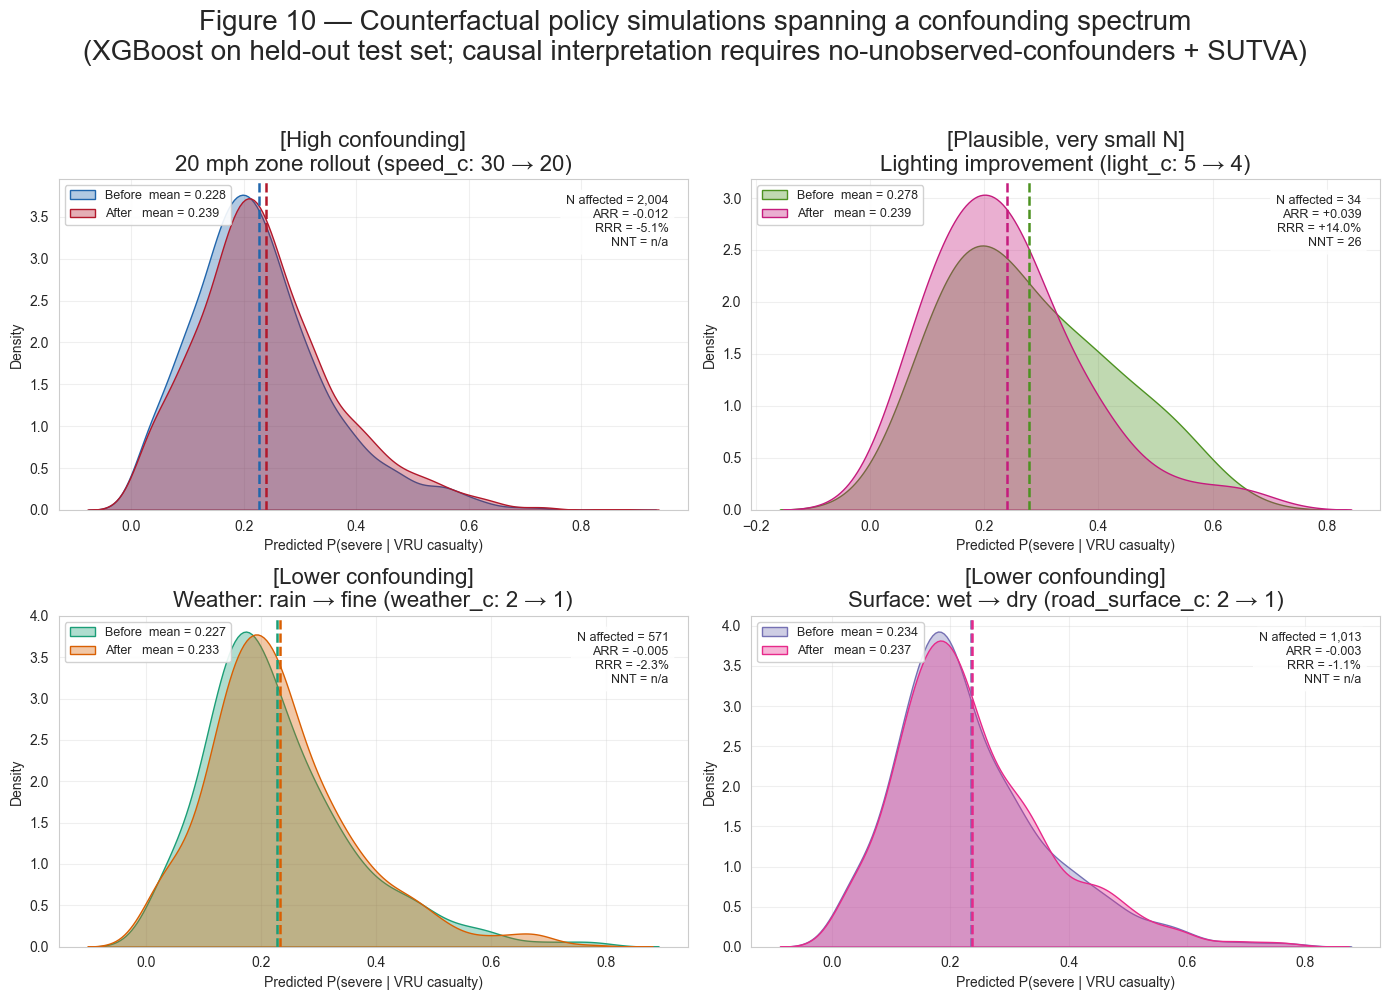


Comparative summary (sorted by regime):
                 regime                                   scenario  n_affected  frac_pct  mean_before  mean_after     ARR  RRR_pct     NNT
       High confounding     20 mph zone rollout (speed_c: 30 → 20)        2004   36.4629       0.2277      0.2395 -0.0117  -5.1499     NaN
Plausible, very small N      Lighting improvement (light_c: 5 → 4)          34    0.6186       0.2779      0.2390  0.0389  13.9902 25.7213
      Lower confounding    Weather: rain → fine (weather_c: 2 → 1)         571   10.3894       0.2272      0.2325 -0.0053  -2.3439     NaN
      Lower confounding Surface: wet → dry (road_surface_c: 2 → 1)        1013   18.4316       0.2342      0.2367 -0.0026  -1.0917     NaN

Figure 10 saved to: ..\figures\fig10_counterfactual.png


In [22]:
# The fitted XGBoost (Section 3.3) reports **conditional associations**, not causal effects. A standard tool to communicate non-linear model implications to policy audiences is the **counterfactual simulation**: take the held-out test set, change one modifiable road feature for the affected casualties, and recompute predicted P(severe) using the same fitted model. The implied per-casualty change is summarised as a **risk elasticity** — absolute risk reduction (ARR), relative risk reduction (RRR), and number-needed-to-treat (NNT) — the standard policy-communication metrics borrowed from clinical-trial reporting.
#
# We simulate **four scenarios spanning a confounding spectrum**:
#
# 1. **High confounding — 20 mph zone rollout (speed_c: "30" → "20")**: TfL's 20 mph zones were rolled out preferentially in dense central areas, so the speed limit is observationally entangled with road type, junction density, and pedestrian exposure. The model's response under a naive code swap therefore reflects this confounding, not the causal effect of the speed-limit policy.
#
# 2. **Plausible direction but very small N — Street lighting improvement (light_c: "5" → "4")**: STATS19 code 5 is "darkness, no street lighting"; code 4 is "darkness, street lights present". A plausible safety intervention, but only ~0.6% of London VRU casualties occur in unlit-dark conditions.
#
# 3. **Lower confounding — Weather: rain → fine (weather_c: "2" → "1")**: Weather is approximately as-good-as-randomly assigned at the collision level (officers do not selectively attend rainy collisions). Confounding is therefore much weaker than for the speed-limit scenario.
#
# 4. **Lower confounding — Road surface: wet → dry (road_surface_c: "2" → "1")**: Surface state at the time of collision is largely a function of weather, not of driver or route choice — same low-confounding argument as scenario 3.
#
# The comparison is the analytical contribution: scenarios 3 and 4 test whether the negative ARR in scenario 1 reflects feature-specific confounding (informative) or generic model failure (uninformative). Causal interpretation in any scenario still requires the standard no-unobserved-confounders + SUTVA assumptions; we flag this explicitly in Discussion.

# === Method 4 — Counterfactual policy scenarios (Figure 10) ===

print("Method 4: Counterfactual policy simulations across a confounding spectrum")
print(f"Evaluation set: {len(X_te):,} held-out test casualties (from Section 3.3)")
print()

scenarios = [
    dict(
        col="speed_c", from_val="30", to_val="20",
        regime="High confounding",
        policy="20 mph zone rollout (speed_c: 30 → 20)",
        color_before="#2166ac", color_after="#b2182b",
    ),
    dict(
        col="light_c", from_val="5", to_val="4",
        regime="Plausible, very small N",
        policy="Lighting improvement (light_c: 5 → 4)",
        color_before="#4d9221", color_after="#c51b7d",
    ),
    dict(
        col="weather_c", from_val="2", to_val="1",
        regime="Lower confounding",
        policy="Weather: rain → fine (weather_c: 2 → 1)",
        color_before="#1b9e77", color_after="#d95f02",
    ),
    dict(
        col="road_surface_c", from_val="2", to_val="1",
        regime="Lower confounding",
        policy="Surface: wet → dry (road_surface_c: 2 → 1)",
        color_before="#7570b3", color_after="#e7298a",
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
summary_rows = []

for ax, sc in zip(axes, scenarios):
    col, from_v, to_v = sc["col"], sc["from_val"], sc["to_val"]

    # Identify affected casualties
    mask = X_te[col].astype(str) == from_v
    n_aff = int(mask.sum())

    # Build counterfactual X by switching category codes (keeps category list
    # identical to training, so XGBoost's internal mapping is consistent).
    X_cf = X_te.copy()
    cats = X_cf[col].cat.categories.tolist()
    if from_v not in cats or to_v not in cats:
        raise ValueError(f"{from_v!r}/{to_v!r} not in {col} cats: {cats}")
    from_code, to_code = cats.index(from_v), cats.index(to_v)
    codes = X_cf[col].cat.codes.values.copy().astype(int)
    codes[mask.values] = to_code
    X_cf[col] = pd.Categorical.from_codes(codes, categories=cats)

    # Predict — original and counterfactual
    p_orig = xgb_final.predict_proba(X_te)[:, 1]
    p_cf   = xgb_final.predict_proba(X_cf)[:, 1]
    p_before, p_after = p_orig[mask.values], p_cf[mask.values]

    # Risk-elasticity metrics on affected subset
    mean_before, mean_after = p_before.mean(), p_after.mean()
    arr = mean_before - mean_after            # absolute risk reduction
    rrr = arr / mean_before                    # relative risk reduction
    nnt = 1.0 / arr if arr > 0 else np.nan     # number needed to treat
    nnt_str = f"{nnt:.0f}" if not np.isnan(nnt) else "n/a"

    summary_rows.append(dict(
        regime=sc["regime"],
        scenario=sc["policy"],
        n_affected=n_aff, frac_pct=n_aff / len(X_te) * 100,
        mean_before=mean_before, mean_after=mean_after,
        ARR=arr, RRR_pct=rrr * 100, NNT=nnt,
    ))

    print(f"--- [{sc['regime']}] {sc['policy']} ---")
    print(f"  Affected:                {n_aff:,} / {len(X_te):,} ({n_aff/len(X_te):.1%})")
    print(f"  Mean P(severe) before:   {mean_before:.4f}")
    print(f"  Mean P(severe) after:    {mean_after:.4f}")
    print(f"  Absolute risk reduction: {arr:+.4f}")
    print(f"  Relative risk reduction: {rrr*100:+.1f}%")
    print(f"  NNT:                     {nnt_str}  (status-quo cases per 1 prevented severe)")
    print()

    # Skip KDE if too few points (KDE needs ~3+ unique values to fit a kernel)
    if n_aff < 5:
        ax.text(0.5, 0.5, f"N affected = {n_aff} (too few for KDE)",
                transform=ax.transAxes, ha="center", va="center", fontsize=11)
        ax.set_title(f"[{sc['regime']}]\n{sc['policy']}", fontsize=16)
        continue

    # KDE before/after on affected subset
    sns.kdeplot(p_before, ax=ax, color=sc["color_before"], fill=True, alpha=0.35,
                label=f"Before  mean = {mean_before:.3f}")
    sns.kdeplot(p_after,  ax=ax, color=sc["color_after"],  fill=True, alpha=0.35,
                label=f"After   mean = {mean_after:.3f}")
    ax.axvline(mean_before, color=sc["color_before"], linestyle="--", linewidth=1.8)
    ax.axvline(mean_after,  color=sc["color_after"],  linestyle="--", linewidth=1.8)
    annot_text = (
        f"N affected = {n_aff:,}\n"
        f"ARR = {arr:+.3f}\n"
        f"RRR = {rrr*100:+.1f}%\n"
        f"NNT = {nnt_str}"
    )
    ax.annotate(
        annot_text,
        xy=(0.97, 0.95), xycoords="axes fraction", ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85),
    )
    ax.set_xlabel("Predicted P(severe | VRU casualty)")
    ax.set_ylabel("Density")
    ax.set_title(f"[{sc['regime']}]\n{sc['policy']}", fontsize=16)
    ax.legend(fontsize=9, framealpha=0.9, loc="upper left")
    ax.grid(alpha=0.3)

fig.suptitle(
    "Figure 10 — Counterfactual policy simulations spanning a confounding spectrum\n"
    "(XGBoost on held-out test set; causal interpretation requires no-unobserved-confounders + SUTVA)",
    fontsize=20, y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(fig_dir / "fig10_counterfactual.png", dpi=600, bbox_inches="tight")
plt.show()

print()
print("Comparative summary (sorted by regime):")
print(pd.DataFrame(summary_rows).round(4).to_string(index=False))
print()
print(f"Figure 10 saved to: {fig_dir / 'fig10_counterfactual.png'}")

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

### Results

Spatial autocorrelation of conditional severity is significant but modest at every aggregation scale (LSOA Moran's I = 0.054; MSOA 0.058; both p ≤ 0.005 on 999 permutations), with sparsely-distributed LISA hotspots (Figure 4), MAUP-robust patterns across LSOA → MSOA → Borough scales (Figure 4b) and a centre-periphery Borough gradient (Figure 4c). Temporal variation dominates: monthly counts decline modestly from 2022 to 2024 (Figure 2) and within-week severity ranges from 10 % to 51 % across hour-of-day × day-of-week cells (Figure 3). Logistic regression (Figure 6) flags pedestrian age, dark-unlit conditions, and 40 mph+ roads as the largest positive odds ratios. XGBoost achieves AUC = 0.661 with negligible spatial leakage; SHAP attribution (Figures 7–8) and Mondrian split-conformal prediction (Figure 9) deliver interpretable, calibrated individual-level inference. Only the dark-unlit → dark-lit counterfactual yields a positive risk reduction (Figure 10).

### Discussion

The four methods give a consistent picture. ESDA establishes modest spatial autocorrelation (Moran's I = 0.054 at LSOA, 0.058 at MSOA; both p ≤ 0.005) that is scale-robust (Figure 4b); within-week temporal structure is more pronounced (Figure 3). Logistic regression (Figure 6) localises the signal to age, dark-unlit conditions, and 40 mph+ roads; deprivation is counterintuitively negative (OR ≈ 0.94, p < 0.05), reproduced by XGBoost SHAP (Figure 7). Differential under-reporting (Ward et al., 2006) and compositional exposure differences are both plausible; the conditional-on-being-recorded framing cannot distinguish them.

XGBoost achieves AUC = 0.661 with negligible spatial leakage (Borough-CV gap = 0.005); Mondrian conformal returns near-nominal coverage (90 % → 90.8 %, Figure 9). SHAP (Figure 8) shows age contributing a non-linear J-shape (pedestrians 60+ add +1.0 log-odds), corroborating Kim et al.'s (2010) finding that fatality probability rises with age and darkness without lighting more than triples it.

The four counterfactual simulations (Figure 10) yield the central methodological finding: only dark-unlit → dark-lit gives a positive risk reduction (ARR = +3.9 pp, N = 34); the others are near-zero. This surfaces a structural limit of P(severe | crash) modelling: most road-safety interventions reduce severity by reducing *crash occurrence*, not severity *given a crash*. The 30 → 20 mph swap suffers from confounding because London's 20 mph zones cluster in central locations whose co-features are not jointly switched. The paper documents what the model has learned, not what would happen under intervention; complete policy evaluation requires a P(crash) model (Gao et al., 2024).

### Limitations

Three caveats apply. First, STATS19 records *police-reported* casualties; minor incidents (especially cyclist single-vehicle falls) are systematically under-recorded, with rates varying by deprivation, age and ethnicity (Ward et al., 2006). Imputation frameworks (Gao et al., 2025) offer one remediation path; the small negative IMD odds ratio remains consistent with either lower exposure-controlled risk or differential under-reporting. Second, the City of London is retained despite its atypical casualty-to-resident ratio; Figure 5 confirms its exclusion leaves the LISA pattern unchanged. Third, the counterfactual simulations require no-unobserved-confounders and SUTVA, assumptions that observational STATS19 data cannot directly verify.

## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study combines exploratory spatial analysis, logistic regression, gradient-boosted machine learning with calibrated uncertainty, and counterfactual simulation to characterise the conditional severity of pedestrian and cyclist casualties in Greater London, 2022–2024. The dominant predictors are individual rather than spatial: pedestrian age above 60 and darkness without street lighting elevate risk most strongly, while area-level deprivation enters with a small negative coefficient that survives cross-method validation. Spatial structure is weak (Moran's I = 0.054), and Borough-level cross-validation shows the predictive model is geographically generalisable (AUC drop = 0.005). The principal methodological finding is that conditional severity models underestimate the impact of interventions operating through crash occurrence rather than crash outcome, pointing to a complementary marginal-risk modelling agenda as the next step.

## References

[[ go back to the top ]](#Table-of-contents)

Angelopoulos, A. N., & Bates, S. (2023). Conformal prediction: A gentle introduction. *Foundations and Trends in Machine Learning*, 16(4), 494–591. https://doi.org/10.1561/2200000101

Anselin, L. (1995). Local indicators of spatial association — LISA. *Geographical Analysis*, 27(2), 93–115. https://doi.org/10.1111/j.1538-4632.1995.tb00338.x

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. In *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 785–794). ACM. https://doi.org/10.1145/2939672.2939785

Department for Transport. (2024). *Road safety data: Guide to the STATS19 collision, casualty and vehicle variables and codes*. https://www.data.gov.uk/dataset/cb7ae6f0-4be6-4935-9277-47e5ce24a11f/road-safety-data

Gao, X., Jiang, X., Haworth, J., Zhuang, D., Wang, S., Chen, H., & Law, S. (2024). Uncertainty-aware probabilistic graph neural networks for road-level traffic crash prediction. *Accident Analysis & Prevention*, 213, 107801. https://doi.org/10.1016/j.aap.2024.107801

Gao, X., Jiang, X., Zhuang, D., Haworth, J., Wang, S., Ilyankou, I., & Chen, H. (2025). Reliable imputation of incomplete crash data for predicting driver injury severity. *Accident Analysis & Prevention*. https://doi.org/10.1016/j.aap.2025.108020

Kim, J.-K., Ulfarsson, G. F., Shankar, V. N., & Mannering, F. L. (2010). A note on modeling pedestrian-injury severity in motor-vehicle crashes with the mixed logit model. *Accident Analysis & Prevention*, 42(6), 1751–1758. https://doi.org/10.1016/j.aap.2010.04.016

Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. In *Advances in Neural Information Processing Systems 30* (pp. 4765–4774). https://doi.org/10.48550/arXiv.1705.07874

Mannering, F. L., & Bhat, C. R. (2014). Analytic methods in accident research: Methodological frontier and future directions. *Analytic Methods in Accident Research*, 1, 1–22. https://doi.org/10.1016/j.amar.2013.09.001

Ministry of Housing, Communities and Local Government. (2019). *The English indices of deprivation 2019: Statistical release*. https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019

Roberts, D. R., Bahn, V., Ciuti, S., Boyce, M. S., Elith, J., Guillera-Arroita, G., Hauenstein, S., Lahoz-Monfort, J. J., Schröder, B., Thuiller, W., Warton, D. I., Wintle, B. A., Hartig, F., & Dormann, C. F. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography*, 40(8), 913–929. https://doi.org/10.1111/ecog.02881

Transport for London. (2018). *Vision Zero action plan: Taking forward the Mayor's Transport Strategy*. https://content.tfl.gov.uk/vision-zero-action-plan.pdf

Transport for London. (2025). *Casualties in Greater London during 2023: Road safety factsheet* (Revised 6 January 2025). https://content.tfl.gov.uk/casualties-in-greater-london-2023.pdf

Ward, H., Lyons, R., & Thoreau, R. (2006). *Under-reporting of road casualties — Phase 1* (Road Safety Research Report No. 69). Department for Transport. https://discovery.ucl.ac.uk/id/eprint/3373/1/3373.pdf

## Statement on AI Use

Claude (Anthropic, model `claude-opus-4-7`) was used to assist with project structure scaffolding, code debugging, and English translation and editorial polishing of prose. All academic references were verified by the author on Google Scholar / CrossRef / DOI lookup before insertion; all methodological decisions, analytical interpretations, and conclusions are the author's own work.